<a href="https://colab.research.google.com/github/KaitoEight/vjp/blob/main/search_tool/GDGC_Unleashing_Gemini_2.0's_Search_and_Multimodal_Capabilities.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

Welcome to this Codelab! We'll explore how to leverage Gemini 2.0's built-in Google Search tool for real-time information retrieval, combine it with multimodal capabilities, and build practical applications with the Google Gen AI SDK.


# Setup Section

## 1. Install Dependencies and Setup Environment

### Install the Google Gen AI SDK
### !pip install -U -q google-genai matplotlib pandas plotly python-dateutil

In [1]:
!pip install -U -q google-genai matplotlib pandas plotly python-dateutil

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.7/159.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 7.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.


In [12]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from IPython.display import display, HTML, Markdown
from google.colab import userdata

print("--- 1. Setting up environment ---")
print("# Required packages installed. Setting up your API key next.")

# Load the API key from Colab secrets
# For security, we use Colab's userdata feature
try:
    # @markdown Make sure you have saved your Google AI API key as a Colab secret named 'GOOGLE_API_KEY'
    os.environ['GOOGLE_API_KEY_1'] = userdata.get('GOOGLE_API_KEY')
    print("✅ API key loaded successfully!")
except Exception as e:
    print(f"❌ Error loading API key: {e}")
    print("Please set up your API key by following these steps:")
    print("1. Go to https://ai.google.dev/ to get your API key")
    print("2. In Colab, go to 'Secrets' in the left sidebar")
    print("3. Add a new secret named 'GOOGLE_API_KEY' with your key as the value")
    print("4. Re-run this cell")


--- 1. Setting up environment ---
# Required packages installed. Setting up your API key next.
✅ API key loaded successfully!


# Gemini Model Initialization
## 2. Initialize Gemini 2.0 Model

In [3]:
from google import genai

# Initialize the client with your API key
client = genai.Client(api_key=os.environ['GOOGLE_API_KEY'],
                     http_options={'api_version': 'v1alpha'})


# Available models - uncomment the one you want to use
MODEL = 'gemini-2.0-flash'  # Fast, good for quick searches and responses
MODEL_PRO = 'gemini-2.5-pro-exp-03-25'  # More capable but slower, and often being overloaded
#MODEL = 'gemini-2.0-flash-thinking-exp-01-21'

print(f"✅ Using model: {MODEL}")
print("# Note: Different models have different capabilities and pricing.")
print("# The 'flash' model is faster while 'pro' is more capable.")

✅ Using model: gemini-2.0-flash
# Note: Different models have different capabilities and pricing.
# The 'flash' model is faster while 'pro' is more capable.


# Helper Functions
## 3. Define Helper Functions for Response Display

In [4]:
def show_parts(response):
    """Display various parts of a Gemini response including text, code, and search results."""
    parts = response.candidates[0].content.parts

    if parts is None:
        finish_reason = response.candidates[0].finish_reason
        print(f'Finish reason: {finish_reason}')
        return

    for part in response.candidates[0].content.parts:
        if part.text:
            display(Markdown(part.text))
        elif hasattr(part, 'executable_code') and part.executable_code:
            display(Markdown(f'```python\n{part.executable_code.code}\n```'))
        else:
            print("Other part type:")
            print(json.dumps(part.model_dump(exclude_none=True), indent=2))

    # Display search results if any
    grounding_metadata = response.candidates[0].grounding_metadata
    if grounding_metadata and grounding_metadata.search_entry_point:
        print("\n📊 Search Results Used:")
        display(HTML(grounding_metadata.search_entry_point.rendered_content))

In [5]:
def visualize_search_usage(responses):
    """Create a visualization of how many searches were used in responses."""
    search_counts = []

    # Process multiple responses to count search usage
    for i, resp in enumerate(responses):
        count = 0
        if hasattr(resp.candidates[0], 'grounding_metadata') and resp.candidates[0].grounding_metadata:
            meta = resp.candidates[0].grounding_metadata
            if hasattr(meta, 'search_entry_point') and meta.search_entry_point:
                # Count the number of search queries
                count = len(meta.search_entry_point.references) if hasattr(meta.search_entry_point, 'references') else 1
        search_counts.append(count)

    # Create a simple bar chart
    plt.figure(figsize=(10, 5))
    plt.bar(range(len(search_counts)), search_counts, color='skyblue')
    plt.xlabel('Query Number')
    plt.ylabel('Number of Searches Used')
    plt.title('Search Utilization per Query')
    plt.xticks(range(len(search_counts)))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


In [6]:
print("✅ Helper functions defined for displaying responses and visualizing search usage")
print("# These functions will help us examine how Gemini uses search and processes information.")

✅ Helper functions defined for displaying responses and visualizing search usage
# These functions will help us examine how Gemini uses search and processes information.


# Basic Search Example

## 4. Comparing Responses With and Without Search



In [13]:
print("\n--- 4. Basic Search Comparison Demo ---")
print("# Let's compare how Gemini responds with and without search capabilities")

# Chat without search
regular_chat = client.chats.create(model=MODEL)

q4 = "What are the latest developments in quantum computing?"
print("\n📝 Query without search: '{}'".format(q4))
regular_response = regular_chat.send_message(q4)
print("\n🤖 Response WITHOUT search tool:")
show_parts(regular_response)

# Wait a moment before next query
time.sleep(2)

# Chat with search enabled
search_tool = {'google_search': {}}
search_chat = client.chats.create(model=MODEL, config={'tools': [search_tool]})

print("\n📝 Same query WITH search: '{}'".format(q4))
search_response = search_chat.send_message(q4)
print("\n🤖 Response WITH search tool:")
show_parts(search_response)

print("\n# Notice the differences in specificity, recency, and detail between the two responses.")
print("# The search-enabled response can cite recent developments and specific breakthroughs.")


--- 4. Basic Search Comparison Demo ---
# Let's compare how Gemini responds with and without search capabilities

📝 Query without search: 'What are the latest developments in quantum computing?'

🤖 Response WITHOUT search tool:


Quantum computing is a rapidly evolving field with new developments happening constantly. Here's a summary of some of the latest advancements across different areas:

**1. Hardware Improvements:**

*   **Increased Qubit Count and Quality:**
    *   **IBM:**  Continuing on its roadmap, IBM has been consistently increasing qubit counts with new processors like the Heron and Condor families.  A major focus is also on improving qubit coherence times (how long qubits can maintain their quantum state) and reducing error rates.
    *   **Google:** Similarly, Google is pushing the boundaries of qubit numbers and fidelity, with ongoing research into their Sycamore processor architecture.
    *   **Quantinuum:** A merger of Honeywell Quantum Solutions and Cambridge Quantum, Quantinuum focuses on trapped-ion technology, known for high fidelity qubits, and is working to scale up their systems.
    *   **Other Players:**  IonQ (trapped ions), Rigetti (superconducting),  PsiQuantum (photonics), and many others are all working on different hardware platforms, each with its own strengths and challenges.
*   **Error Correction:**
    *   **Logical Qubits:** A major push is towards building logical qubits.  These are multiple physical qubits combined to form a more stable, error-resistant qubit. While still early stages, significant progress is being made in creating and controlling these logical qubits.
    *   **Error Mitigation:**  Techniques to mitigate the impact of errors on quantum computations are improving.  These methods don't eliminate errors, but they can help to reduce their effect on the final result.
*   **Cryogenic Control and Interconnects:**
    *   Developing better cryogenic control systems to manage the complex wiring and control signals needed for large-scale quantum computers is crucial.
    *   Research into more efficient and scalable interconnects within the cryogenic environment is ongoing.

**2. Software and Algorithm Development:**

*   **Quantum Algorithms:**
    *   **New Algorithms:** While Shor's algorithm (factoring) and Grover's algorithm (search) are well-known, researchers are constantly developing new quantum algorithms for various applications, including:
        *   **Quantum Machine Learning:** Algorithms for faster machine learning training and inference.
        *   **Quantum Chemistry:** Simulating molecules and materials with unprecedented accuracy.
        *   **Optimization:** Solving complex optimization problems in logistics, finance, and other fields.
    *   **Variational Quantum Algorithms (VQAs):**  VQAs are a hybrid quantum-classical approach that is more suitable for near-term quantum computers. These are being actively explored for a wide range of applications.
*   **Quantum Software Development Kits (SDKs):**
    *   **Improved Tools:**  IBM's Qiskit, Google's Cirq, Microsoft's Q#, and other SDKs are becoming more user-friendly and powerful. They offer tools for writing, simulating, and running quantum programs on different hardware platforms.
    *   **High-Level Abstractions:**  Efforts are being made to develop higher-level programming languages and abstractions that make it easier for developers to write quantum programs without needing deep expertise in quantum physics.
*   **Quantum Compilers:**
    *   Quantum compilers translate high-level quantum code into machine code that can be executed on a specific quantum computer. Improving compiler optimization is critical to maximize the performance of quantum programs.

**3. Applications and Use Cases:**

*   **Quantum Chemistry and Materials Science:** Simulating molecules to discover new drugs, catalysts, and materials. This is considered one of the most promising near-term applications.
*   **Drug Discovery:**  Using quantum simulations to identify potential drug candidates and optimize drug design.
*   **Financial Modeling:** Developing quantum algorithms for portfolio optimization, risk management, and fraud detection.
*   **Logistics and Supply Chain Optimization:** Solving complex routing and scheduling problems using quantum optimization algorithms.
*   **Machine Learning:** Developing quantum machine learning algorithms for tasks like classification, clustering, and feature selection.
*   **Cryptography:**  While quantum computers pose a threat to current encryption methods, research is also focused on developing quantum-resistant cryptography.  Quantum Key Distribution (QKD) is also being explored for secure communication.

**4.  Ecosystem and Industry Growth:**

*   **Increased Investment:**  Significant investments are being made by governments, venture capitalists, and corporations in quantum computing research and development.
*   **Growing Workforce:**  There is a growing demand for quantum computing scientists, engineers, and developers.  Universities and companies are expanding their quantum education and training programs.
*   **Standardization Efforts:**  Organizations are working to establish standards for quantum computing hardware, software, and protocols. This will help to ensure interoperability and accelerate the development of the field.

**Specific Recent Examples (as of late 2023/early 2024):**

*   **IBM's Heron processor:**  Showcased improved error rates and control compared to previous generations.  IBM continues to release and update cloud-accessible quantum computers.
*   **Google's focus on error correction:** Publishing research on creating more robust logical qubits using their superconducting platform.
*   **Advancements in Quantum Machine Learning:** New algorithms and implementations are being published at major machine learning conferences, showcasing the potential of quantum computers to accelerate certain ML tasks.
*   **Quantum simulation breakthroughs:** Reports of increasingly complex and accurate simulations of molecular properties, bringing quantum chemistry applications closer to reality.
*   **Growing quantum cloud services:** More companies are offering access to quantum computers via the cloud, making it easier for researchers and developers to experiment with the technology.

**Challenges Remaining:**

*   **Scalability:** Building quantum computers with a large number of high-quality qubits remains a significant challenge.
*   **Decoherence:**  Maintaining the quantum state of qubits is difficult due to interactions with the environment (decoherence).
*   **Error Correction:**  Implementing effective quantum error correction is essential to build fault-tolerant quantum computers.
*   **Algorithm Development:**  Developing new and practical quantum algorithms that can outperform classical algorithms for real-world problems is crucial.
*   **Quantum Software Development:**  Making quantum programming more accessible and user-friendly.

**In summary, the latest developments in quantum computing show steady progress in hardware, software, and algorithm development. While fully fault-tolerant, universal quantum computers are still some years away, the field is rapidly advancing, and researchers are exploring a wide range of applications that could potentially revolutionize various industries.**

To stay up-to-date, I recommend following reputable sources such as:

*   **Scientific journals:** *Nature*, *Science*, *Physical Review Letters*, etc.
*   **Quantum computing news websites:**  Quantum Computing Report, Inside Quantum Technology, etc.
*   **Company websites:** IBM Quantum, Google AI Quantum, Quantinuum, IonQ, Rigetti, etc.
*   **Conferences:**  American Physical Society (APS) March Meeting, Quantum.Tech, Q2B, etc.



📝 Same query WITH search: 'What are the latest developments in quantum computing?'

🤖 Response WITH search tool:


The latest developments in quantum computing include:

*   **Quantum Hardware Advancements:** Development of hypercube network technologies to enhance scalability and performance, and integrated photonics for scalable quantum computing with trapped ions.
*   **Post-Quantum Cryptography:** Focus on developing cryptographic algorithms to secure data against quantum threats.
*   **Quantum Machine Learning Integration:** Integration of machine learning with quantum systems to enhance computational power, with frameworks like TorchQC enabling deep learning techniques in quantum dynamics and control.
*   **Materials for Quantum Hardware:** Development of innovative materials like germanium and GeSn-based quantum well lasers to improve quantum hardware efficiency and performance.
*   **Quantum Error Correction:** Progress made by researchers and companies like Google, QueRa, IBM and CSIRO on quantum error corrections.
*   **Logical Qubits:** Development of logical qubits, which are protected from errors and have very high fidelity, with major quantum chip developers shifting their focus from physical qubits to logical qubits.
*   **Quantum Foundries:** Development of facilities designed for scalable production of qubits to reduce costs and standardize components.
*   **Quantum Security:** Deployment of quantum-resistant algorithms to safeguard digital infrastructure, with potential rollouts in finance, defense, and critical infrastructure sectors.
*   **Quantum AI Synergy:** Hybrid models leveraging quantum computing for optimization, generative AI for quantum problem-solving, and AI-driven error correction.
*   **Networking of NISQ Devices:** Interconnecting multiple quantum computers to create a single virtual quantum computer with a higher qubit count.
*   **Quantum memory:** Demonstration of quantum memory with below-threshold error rates and double the coherence lifetimes as compared with physical qubits.
*   **Topological Qubits:** Development of quantum computers based on topological qubits, with Microsoft introducing the Majorana 1 chip, the world's first quantum processor powered by topological qubits.
*   **Quantum Technology Beyond Computing:** Expansion of quantum technology beyond computing, with opportunities in quantum sensing and quantum communication.

As of March 2025, there are around 100 to 200 quantum computers in existence. The number of quantum computers is expected to grow exponentially in the coming years, with McKinsey estimating that there will be 5,000 operational quantum computers by 2030.



📊 Search Results Used:



# Notice the differences in specificity, recency, and detail between the two responses.
# The search-enabled response can cite recent developments and specific breakthroughs.


# Follow-up Questions Example
## 5. Asking Follow-up Questions in a Search Context

In [14]:
print("\n--- 5. Follow-up Questions with Search ---")
print("# Gemini can maintain context while using search for follow-up questions")

follow_up_chat = client.chats.create(model=MODEL, config={'tools': [search_tool]})

# List to store responses for visualization
follow_up_responses = []
q5_1 = "What are the top 3 electric vehicles with the longest range?"
print("\n📝 Initial Query: '{}'".format(q5_1))
response1 = follow_up_chat.send_message(q5_1)
show_parts(response1)
follow_up_responses.append(response1)

time.sleep(2)

q5_2 = "How much do they cost?"
print("\n📝 Follow-up Query: '{}'".format(q5_2))
response2 = follow_up_chat.send_message(q5_2)
show_parts(response2)
follow_up_responses.append(response2)

time.sleep(2)

q5_3 = "Compare their charging time"
print("\n📝 Another Follow-up: '{}'".format(q5_3))
response3 = follow_up_chat.send_message(q5_3)
show_parts(response3)
follow_up_responses.append(response3)

# # Visualize search usage across the conversation
# print("\n📊 Search Usage Visualization:")
# visualize_search_usage(follow_up_responses)

print("\n# Notice how Gemini maintains context about which vehicles we're discussing")
print("# while retrieving fresh information for each question.")


--- 5. Follow-up Questions with Search ---
# Gemini can maintain context while using search for follow-up questions

📝 Initial Query: 'What are the top 3 electric vehicles with the longest range?'


Determining the "top" EVs by range can depend on whether you're looking at the manufacturer's claimed range (often WLTP figures) or real-world tested range. It's also important to note that range can vary based on driving conditions, temperature, and other factors.

Here are some of the top contenders for longest-range electric vehicles, based on the latest information available as of April 19, 2025:

**Based on Claimed/Estimated Range:**

1.  **Lucid Air (2025):** This luxury sedan often tops the lists with an estimated range of up to **512 miles.**
2.  **Mercedes-Benz EQS 450+:** Claimed range of **481 miles**.
3.  **Peugeot e-5008:** Boasts a WLTP driving range of **414 miles** thanks to its 97kWh battery pack.

**Based on Real-World Testing:**

1.  **Lucid Air:** Car and Driver's testing saw the Lucid Air achieve **410 miles.**
2.  **Chevrolet Silverado EV:** In Car and Driver's real-world testing, it achieved **400 miles.**
3.  **Mercedes EQS:** Car and Driver's testing saw the EQS achieve **400 miles.**

It's important to consider that these are just a few examples, and the "best" EV for you will depend on your individual needs and preferences.



📊 Search Results Used:



📝 Follow-up Query: 'How much do they cost?'


Okay, let's look at the approximate costs for the top 3 longest-range electric vehicles I mentioned earlier. Please note that pricing can vary depending on the specific trim level, options, and incentives available in your location. Also, these are MSRP (Manufacturer's Suggested Retail Price) estimates and don't include taxes, fees, or potential dealer markups.



Here's a breakdown of the estimated costs:

1.  **Lucid Air (2025):** The Lucid Air has various trims, with prices ranging from approximately **$69,900** for the base Pure trim to **$250,500** for the high-performance Sapphire model.

2.  **Mercedes-Benz EQS 450+ (2025):** The EQS 450+ has a starting MSRP of around **$104,400 - $107,400**. Higher trim levels and options will increase the price.

3.  **Peugeot e-5008 (2025):** The Peugeot e-5008 is expected to start around **£48,660 to £54,890** in the UK. Pricing may vary in other markets.

Keep in mind that these are MSRPs and can change. Always check with local dealers for the most up-to-date pricing and availability.



📊 Search Results Used:



📝 Another Follow-up: 'Compare their charging time'


Alright, let's compare the charging times for the Lucid Air, Mercedes-Benz EQS 450+, and Peugeot e-5008. Charging times for electric vehicles depend on several factors, including the battery capacity, the charging rate of the car, and the power output of the charging station (Level 2 AC or DC fast charging).

Here's a general comparison:

**1. Lucid Air (2025)**

*   **DC Fast Charging:** The Lucid Air is known for its fast charging capabilities. With a DC fast charger at its peak charging rate (around 300kW), it can add up to 200 miles of range in about 15-20 minutes.
*   **Level 2 Charging (240V):** Using a Level 2 charger, a full charge can take around 6-12 hours, depending on the amperage of the charger.

**2. Mercedes-Benz EQS 450+ (2025)**

*   **DC Fast Charging:** The EQS can charge at up to 200kW. At this rate, it can typically add around 180-200 miles of range in about 30 minutes.
*   **Level 2 Charging (240V):** A full charge using a Level 2 charger generally takes around 10-12 hours.

**3. Peugeot e-5008 (2025)**

*   **DC Fast Charging:** The Peugeot e-5008 is compatible with 160kW charging. This means that a 20-80% charge can be completed in 30 minutes.
*   **Level 2 Charging (240V):** A full charge using a Level 2 charger generally takes around 9 hours and 30 minutes.

**Summary Table (Estimates)**

| Feature           | Lucid Air            | Mercedes-Benz EQS 450+ | Peugeot e-5008        |
| ----------------- | -------------------- | ---------------------- | ---------------------- |
| DC Fast Charging  | 200 miles in 15-20 min | 180-200 miles in 30 min | 20-80% in 30 minutes   |
| Level 2 Charging  | 6-12 hours           | 10-12 hours            | Around 9 hours 30 mins |

**Important Considerations:**

*   **Charging Infrastructure:** The availability and speed of charging stations in your area will significantly impact your overall charging experience.
*   **Battery Size:** The larger the battery, the longer it will take to charge, all other factors being equal.
*   **Charging Curve:** Charging speeds often taper off as the battery reaches higher states of charge (e.g., from 80% to 100%), so the last portion of a charge can take longer.

These are estimated charging times, and actual times may vary.



# Notice how Gemini maintains context about which vehicles we're discussing
# while retrieving fresh information for each question.


# Combining Search with Data Visualization
## 6. Creating Data Visualizations with Search-Sourced Data

In [16]:
print("\n--- 6. Data Visualization with Search-Sourced Data ---")
print("# Gemini can use search to find data and generate code to visualize it")

# Create a new chat with search enabled for data visualization
viz_chat = client.chats.create(model=MODEL, config={'tools': [search_tool]})

# Explicitly ask for Python code to visualize the data
viz_prompt = """
Find the GDP growth rates for the world's top 5 economies for the most recent year.
Then write executable Python code that:
1. Creates a pandas DataFrame with this data
2. Uses matplotlib to generate a bar chart comparing the growth rates
3. Includes proper labels, title, and color coding
4. Formats the chart for clear visualization

Make sure the code is complete and can be executed directly in a Jupyter notebook without modification.
"""

print("\n📝 Query: '{}'".format(viz_prompt))
# Adding a delay before sending the message
time.sleep(5)  # Adjust the delay as needed
viz_response = viz_chat.send_message(viz_prompt)
show_parts(viz_response)

print("#\n Gemini has sourced recent economic data and created visualization code.")


--- 6. Data Visualization with Search-Sourced Data ---
# Gemini can use search to find data and generate code to visualize it

📝 Query: '
Find the GDP growth rates for the world's top 5 economies for the most recent year.
Then write executable Python code that:
1. Creates a pandas DataFrame with this data
2. Uses matplotlib to generate a bar chart comparing the growth rates
3. Includes proper labels, title, and color coding
4. Formats the chart for clear visualization

Make sure the code is complete and can be executed directly in a Jupyter notebook without modification.
'


Here's the GDP growth rate information and executable Python code to generate the visualization:

**GDP Growth Rates for Top 5 Economies (2024):**

Based on the provided search results, here are the approximate GDP growth rates for 2024 for the world's top 5 economies:

1.  **United States:** 2.8%
2.  **China:** 4.8%
3.  **Japan:** 0.3%
4.  **Germany:** -0.3%
5.  **India:** 8.15%

**Python Code:**



```python
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data
data = {'Country': ['United States', 'China', 'Japan', 'Germany', 'India'],
        'GDP Growth Rate': [2.8, 4.8, 0.3, -0.3, 8.15]}  # GDP Growth rate data
df = pd.DataFrame(data)

# Plotting
plt.figure(figsize=(10, 6))  # Adjust figure size for better visualization
colors = ['skyblue', 'lightgreen', 'lightcoral', 'lightsalmon', 'lightcyan'] # Define custom colors

bars = plt.bar(df['Country'], df['GDP Growth Rate'], color=colors)

# Adding labels and title
plt.xlabel('Country', fontsize=12)
plt.ylabel('GDP Growth Rate (%)', fontsize=12)
plt.title('GDP Growth Rates of Top 5 Economies (2024)', fontsize=14)
plt.xticks(rotation=45, ha='right') # Rotate country names for readability

# Adding value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.grid(axis='y', linestyle='--')  # Add a grid for easier reading

plt.show()
```



**Explanation:**

1.  **Import Libraries:** Import `pandas` for creating a DataFrame and `matplotlib.pyplot` for plotting.
2.  **Create DataFrame:** A pandas DataFrame is created with the country names and their GDP growth rates.
3.  **Plotting:**
    *   A bar chart is generated using `plt.bar()`.
    *   Custom colors are defined for the bars.
4.  **Labels and Title:**  The chart is labeled with appropriate titles for the axes and the chart itself.
5.  **X-axis Ticks:** Country names are rotated for better readability.
6.  **Value Labels:** The GDP growth rate is displayed on top of each bar using `plt.text()`.
7.  **Layout Adjustment:** `plt.tight_layout()` ensures that all labels fit within the figure without overlapping.
8.  **Grid:** A grid is added to the y-axis to help in reading the values.
9.  **Display Chart:** `plt.show()` displays the chart.



📊 Search Results Used:


#
 Gemini has sourced recent economic data and created visualization code.


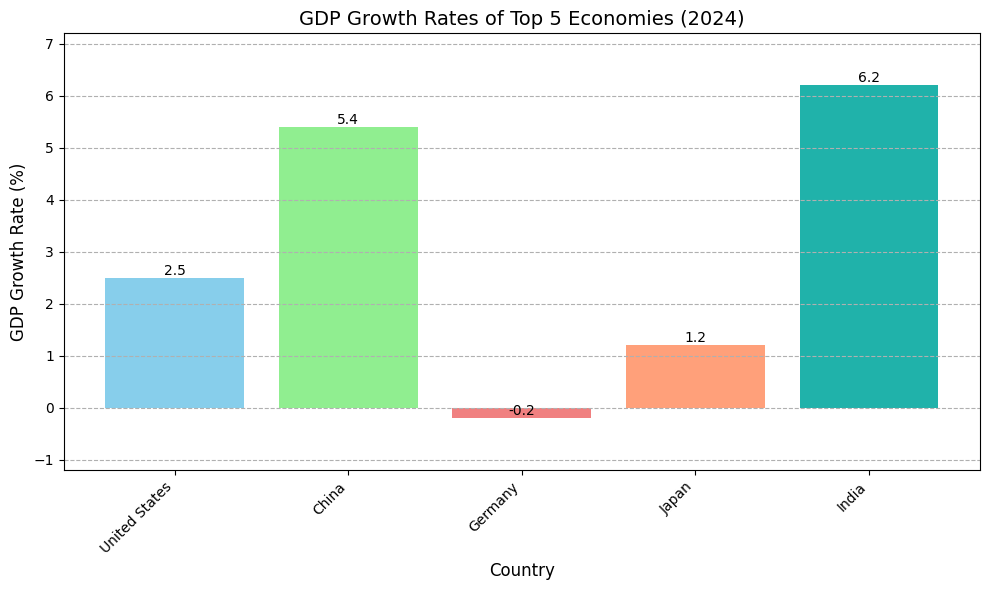

In [17]:
#Visualized the generated code

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data
data = {'Country': ['United States', 'China', 'Germany', 'Japan', 'India'],
        'GDP Growth Rate': [2.5, 5.4, -0.2, 1.2, 6.2]}

df = pd.DataFrame(data)

# Plotting
plt.figure(figsize=(10, 6))  # Adjust figure size for better visualization
colors = ['skyblue', 'lightgreen', 'lightcoral', 'lightsalmon', 'lightseagreen']  # Define colors

bars = plt.bar(df['Country'], df['GDP Growth Rate'], color=colors)

# Adding labels and title
plt.xlabel('Country', fontsize=12)
plt.ylabel('GDP Growth Rate (%)', fontsize=12)
plt.title('GDP Growth Rates of Top 5 Economies (2024)', fontsize=14)
plt.ylim(min(df['GDP Growth Rate']) - 1, max(df['GDP Growth Rate']) + 1) #Set y axis limit based on min/max growth rate.

# Adding value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 1), ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.grid(axis='y', linestyle='--')  # Add a grid for better readability

# Show plot
plt.show()

# Multimodal Search Example
## 7. Combining Search with Multimodal Capabilities


--- 7. Multimodal Search Exploration ---
# Gemini 2.0 can combine search with analysis of uploaded images

In this section, you'll upload an image and Gemini will:
1. Analyze the visual content to identify what's in the image
2. Use Google Search to find accurate, detailed information about the subject
3. Allow you to ask follow-up questions in the same conversation context

This demonstrates how Gemini combines visual understanding with search capabilities.

📸 Let's try this out!
Please upload an image (landmark, artwork, product, etc.)


Saving Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg to Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg
Uploaded image:


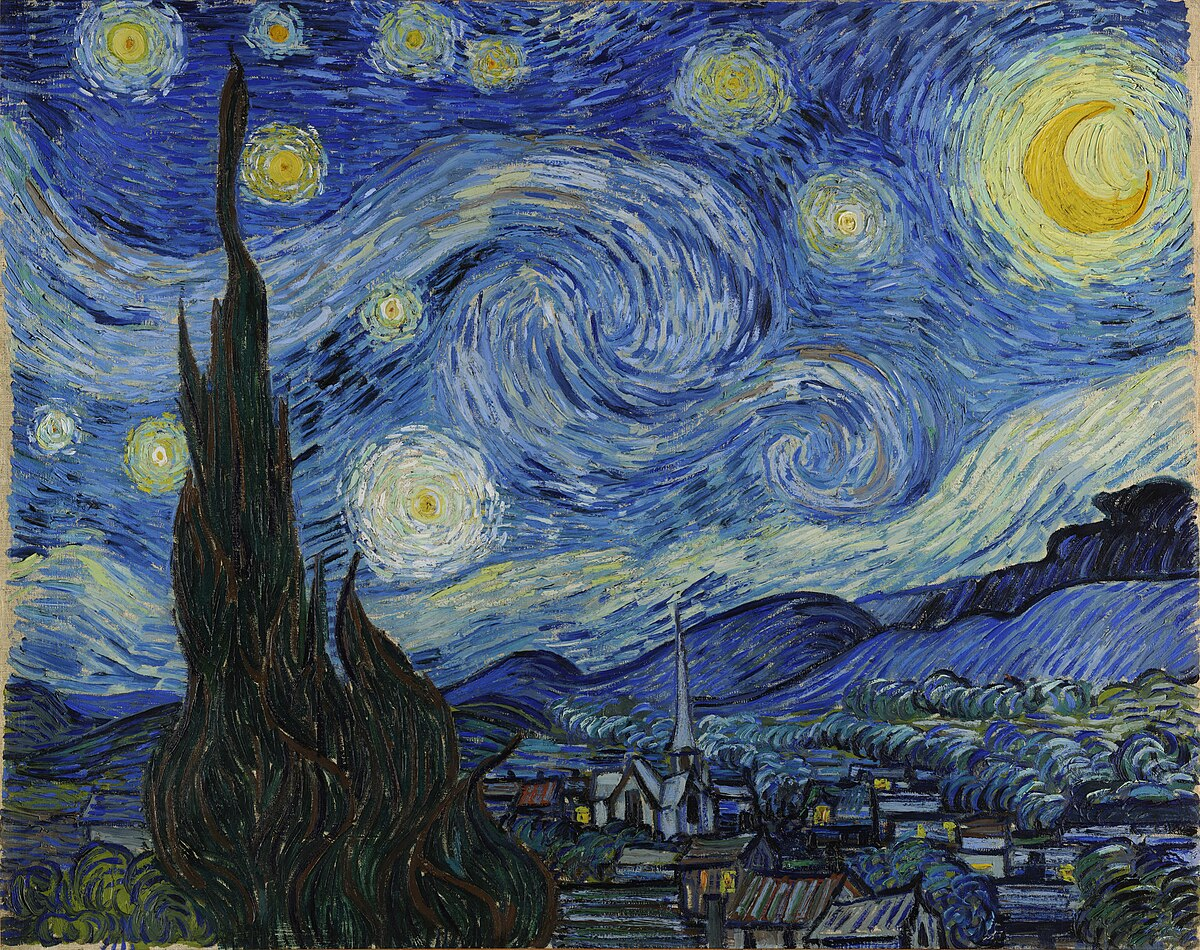


🔍 Analyzing image...


Here's a description of the image, following your requested format:

**Main Subject:** A Starry Night

**Description:** This is Vincent van Gogh's famous painting "The Starry Night," an oil-on-canvas artwork created in 1889. It depicts a vibrant, swirling night sky filled with stars, a crescent moon, and bright orbs, over a small village with a church steeple. A dark, flame-like cypress tree dominates the foreground, connecting the earth and sky. The painting is known for its expressive brushstrokes, contrasting blues and yellows, and the emotional intensity it conveys.



📊 Search Results Used:



🔍 Searching for detailed information...


Here's more detailed information about "The Starry Night":

*   **Creation:** Painted in June 1889 by Vincent van Gogh.
*   **Location:** Saint-Rémy-de-Provence, France, while Van Gogh was residing at the Saint-Paul-de-Mausole asylum.
*   **Medium:** Oil on canvas.
*   **Dimensions:** 73.7 cm × 92.1 cm (29.01 in × 36.26 in).
*   **Current Location:** Museum of Modern Art (MoMA) in New York City since 1941.

**History:**

*   **Inspiration:** The painting depicts the view from the east-facing window of Van Gogh's asylum room just before sunrise, with the addition of an imaginary village.
*   **Mental State:** Van Gogh voluntarily admitted himself to the asylum in May 1889 following a mental breakdown and the infamous ear-cutting incident. He experienced periods of high productivity alternating with despair during his stay.
*   **Post-Impressionism:** "The Starry Night" is a key work of Post-Impressionism, showcasing Van Gogh's expressive use of color and dynamic brushstrokes.
*   **Ownership:** After Van Gogh's death, his brother Theo inherited his paintings. When Theo died, his wife Johanna van Gogh-Bonger inherited the artwork and played a crucial role in promoting Van Gogh's work and building his posthumous fame. She initially sold it to Julien Leclercq, then reacquired it before it went through several owners until MoMA acquired it in 1941.

**Interesting Facts:**

*   **Not Painted En Plein Air:** Although inspired by the view from his window, "The Starry Night" was mainly painted in Van Gogh's studio during the day, not outdoors at night.
*   **Venus and the Moon:** The painting includes the planet Venus, visible in the morning sky at the time. However, the moon's depiction isn't astronomically accurate.
*   **Cypress Tree:** The prominent cypress tree in the foreground has been interpreted in various ways, including as a symbol of death and a connection between the earth and sky. Some view it as a symbol of hope and eternal life.
*   **Village:** The village depicted in the painting is an imaginary addition, not a direct representation of what Van Gogh saw from his window.
*   **Van Gogh's Opinion:** Van Gogh was initially critical of "The Starry Night," even calling it a failure.
*   **Multiple Interpretations:** The painting has been subject to various interpretations, ranging from religious symbolism to expressions of Van Gogh's emotional turmoil.
*   **Night Scenes:** Van Gogh had painted night scenes before, such as "Starry Night Over the Rhone" (1888), exploring the challenges of capturing the night sky.
*   **Modern Art Icon:** "The Starry Night" is regarded as one of the most recognizable paintings in Western art and a touchstone of modern art.
*   **Influence:** The painting has been foundational for Expressionism and continues to inspire artists.
*   **Asylum View:** Van Gogh painted the view from his asylum window approximately 21 times, capturing different times of day, night, and weather conditions.



📊 Search Results Used:



📝 You can now ask follow-up questions about the image!
Example follow-up questions:
- 'How does it compare to similar examples?'
- 'What are common misconceptions about it?'
- 'When was the last major renovation or change?'
Enter a follow-up question (or press Enter to skip): 


In [18]:
print("\n--- 7. Multimodal Search Exploration ---")
print("# Gemini 2.0 can combine search with analysis of uploaded images")

from google.genai.types import HttpOptions, Part
from IPython.display import display, Image
from google.colab import files
import base64
import io

def encode_image(image_path):
    """Encode image to base64 string"""
    with open(image_path, "rb") as image_file:
        return image_file.read()

def upload_and_analyze_image():
    """Upload an image and analyze it with Gemini + Search"""
    print("Please upload an image (landmark, artwork, product, etc.)")
    uploaded = files.upload()

    if not uploaded:
        print("No image uploaded. Skipping image analysis.")
        return

    # Get the first uploaded file
    image_path = list(uploaded.keys())[0]

    # Display the uploaded image
    print("Uploaded image:")
    display(Image(filename=image_path))

    # Encode the image to base64
    image_bytes = encode_image(image_path)

    # Create a new multimodal message with the image
    multimodal_chat = client.chats.create(model=MODEL, config={'tools': [search_tool]})

    # First prompt to identify the image
    identification_prompt = f"""

    What is shown in this image? Please identify the main subject and provide a brief description in format below: \n
    Main Subject: subject \n
    Description: description \n
    """

    print("\n🔍 Analyzing image...")

    multimodal_chat.send_message([Part.from_bytes(data=image_bytes, mime_type="image/jpeg")])
    identification_response = multimodal_chat.send_message(identification_prompt)
    show_parts(identification_response)

    # Second prompt to get more detailed information with search
    detail_prompt = "Please search for more detailed information about this subject, including when it was created/built, its history, and interesting facts."

    print("\n🔍 Searching for detailed information...")
    detail_response = multimodal_chat.send_message(detail_prompt)
    show_parts(detail_response)

    return multimodal_chat

# Explanation for workshop participants
print("\nIn this section, you'll upload an image and Gemini will:")
print("1. Analyze the visual content to identify what's in the image")
print("2. Use Google Search to find accurate, detailed information about the subject")
print("3. Allow you to ask follow-up questions in the same conversation context")
print("\nThis demonstrates how Gemini combines visual understanding with search capabilities.")

# Run the interactive image upload and analysis
print("\n📸 Let's try this out!")
multimodal_chat = upload_and_analyze_image()

# Provide instructions for follow-up questions
if multimodal_chat:
    print("\n📝 You can now ask follow-up questions about the image!")
    print("Example follow-up questions:")
    print("- 'How does it compare to similar examples?'")
    print("- 'What are common misconceptions about it?'")
    print("- 'When was the last major renovation or change?'")

    # Option to ask a follow-up question
    follow_up = input("Enter a follow-up question (or press Enter to skip): ")
    if follow_up:
        print(f"\n🔍 Searching for answer to: '{follow_up}'")
        follow_up_response = multimodal_chat.send_message(follow_up)
        show_parts(follow_up_response)

# Practical Applications

## 8. Practical Applications of Search-Enabled AI

In [19]:
print("\n--- 8. Practical Applications Workshop ---")
print("# Let's explore practical real-world applications of search-enabled AI")

# Create a chat for practical applications
practical_chat = client.chats.create(model=MODEL_PRO, config={'tools': [search_tool]})

application_scenarios = [
    "Research Assistant: Gemini can help gather information, summarize findings, and cite sources for academic papers.",
    "Market Analysis: Search for latest trends, competitors, and customer sentiment for business strategy.",
    "Travel Planning: Get up-to-date information on destinations, travel requirements, and local recommendations.",
    "Health Information: Find recent medical research and health guidelines (with appropriate disclaimers).",
    "Educational Tool: Create learning materials with current facts, figures, and examples."
]

for i, scenario in enumerate(application_scenarios):
    print(f"\n{i+1}. {scenario}")

# Example of market analysis application
q8 = "Analyze the current state of the electric vehicle market in Europe. Include major players, market share, and growth trends."
print("\n📝 Market Analysis Example Query: '{}'".format(q8))
market_response = practical_chat.send_message(q8)
show_parts(market_response)


--- 8. Practical Applications Workshop ---
# Let's explore practical real-world applications of search-enabled AI

1. Research Assistant: Gemini can help gather information, summarize findings, and cite sources for academic papers.

2. Market Analysis: Search for latest trends, competitors, and customer sentiment for business strategy.

3. Travel Planning: Get up-to-date information on destinations, travel requirements, and local recommendations.

4. Health Information: Find recent medical research and health guidelines (with appropriate disclaimers).

5. Educational Tool: Create learning materials with current facts, figures, and examples.

📝 Market Analysis Example Query: 'Analyze the current state of the electric vehicle market in Europe. Include major players, market share, and growth trends.'


Okay, here is an analysis of the current state of the electric vehicle (EV) market in Europe, covering major players, market share, and growth trends based on recent data:

**Current State & Growth Trends**

*   **Maturing Market with Recent Slowdown:** After years of rapid growth, the European EV market showed signs of stagnation or slower growth in 2024 compared to the explosive increases seen previously. For the full year 2024, battery-electric vehicle (BEV) registrations in Europe (EU, EFTA, UK) saw a slight contraction of 1.3% compared to 2023, totaling just under 2 million units (1,993,102). This followed a period where sales grew significantly year-over-year.
*   **Sales Volume:** Despite the percentage slowdown, the absolute number of EVs sold remains substantial. In 2023, nearly 3.2 million new electric cars were registered in Europe, a roughly 20% increase over 2022. Over 2.96 million EVs (BEVs and PHEVs combined) were registered in Europe across 2024, a year-on-year decline of 1.8%. However, recent months towards the end of 2024 and the start of 2025 have shown renewed growth. For instance, plug-in vehicle registrations increased by 6% YoY in September 2024. January 2025 saw a 36.6% YoY increase in BEV registrations.
*   **Market Share:** In 2024, BEVs accounted for approximately 15.4% of all new passenger car registrations in the wider European area (EU+EFTA+UK), slightly down from 15.7% in 2023. Within the EU specifically, the BEV market share was 13.6% for the full year 2024. By early 2025 (Jan-Feb), the BEV share in the EU had risen to 15.2%. When combined with Plug-in Hybrid Electric Vehicles (PHEVs), the market share for plug-ins was around 22% in Europe in 2024. Hybrid electric vehicles (HEVs) are also gaining significant ground, capturing nearly 35% market share in the EU in early 2025.
*   **BEV vs. PHEV Trends:** There's a clear divergence: BEV sales continue to grow (though the pace has fluctuated), while PHEV sales have been declining. BEVs accounted for the majority (67.7%) of the plug-in market in 2024. PHEV registrations dropped in 2024 and continued to decline in early 2025.
*   **Influencing Factors:** The recent slowdown has been attributed to factors like the phasing out or reduction of subsidies in key markets like Germany, carmakers' strategies focusing on higher-margin models, and potentially holding back sales until stricter CO2 targets kick in for 2025. High EV prices, particularly for larger models, have also played a role.
*   **Future Outlook:** Analysts expect significant growth to resume in 2025, driven by stricter EU CO2 regulations forcing manufacturers to sell more EVs, and the launch of more affordable "Made-in-Europe" models. Projections suggest EV sales in Western Europe could rise by 40% to 2.7 million units in 2025, reaching a 22% market share.

**Major Players & Market Share (Based on 2024/Early 2025 Data)**

*   **Leading Brands (EVs - BEV+PHEV):**
    1.  **Tesla:** Remained the top-selling EV brand in Europe for the full year 2024 for the third consecutive year, delivering 328,036 units, although this was a 10.4% decline from 2023. Its market share for plug-ins was 11.1% in 2024. In the first half of 2024, Tesla held an 11.4% market share.
    2.  **BMW:** Secured second place in 2024 with 292,407 EV registrations (a 10.7% increase YoY), achieving a 9.9% market share.
    3.  **Mercedes-Benz:** Took third place in 2024 with 258,677 units (a 10% increase YoY) and an 8.8% market share.
    4.  **Volkswagen (VW):** Dropped to fifth place in 2024, with 229,836 deliveries (a 6.7% decline) and a 7.8% market share. It followed Volvo in fourth place in the first half of 2024 brand rankings.
    5.  **Audi:** Landed sixth in 2024 (172,665 units, -0.8% YoY, 5.8% share).
    6.  **Volvo:** Held an 8.6% market share in the first half of 2024.
    7.  **Kia:** Placed seventh in 2024 (118,264 units, -13% YoY).
*   **Leading Automotive Groups (EVs - BEV+PHEV):**
    1.  **Volkswagen Group:** Maintained its dominant position, holding around 20.8% - 21.5% market share in 2024.
    2.  **Tesla:** Second largest group by market share at around 11.4%.
    3.  **BMW Group:** Held around 11.1% - 10.7% market share.
    4.  **Stellantis:** Market share has been declining, dropping to around 11.2% mid-2024, down from 14.3% a year prior.
    5.  **Geely-Volvo:** Gaining ground, reaching a 10.6% market share mid-2024.
*   **Best-Selling Models:**
    *   **Tesla Model Y:** Was the best-selling electric car model in Europe in 2024, despite a sales drop compared to 2023. It led sales again in September 2024.
    *   **Tesla Model 3:** Remained a strong performer, often placing second.
    *   **Skoda Enyaq:** Showed strong growth, achieving record monthly sales and challenging for top spots. It even topped the chart in October 2024.
    *   Other strong contenders include the Audi Q4 e-tron, Volvo EX30, and VW ID.4.
*   **Emerging Players:** Chinese manufacturers like BYD, MG (SAIC), XPENG, and VinFast are increasingly entering or expanding in the European market, often with competitively priced models, posing a challenge to established European OEMs. BYD, for example, registered over 50,000 units in Europe in 2024. Many European brands like BMW, Volvo, Dacia, and Smart also manufacture some of their EV models in China for the European market.

**Regional Variations**

*   Market penetration varies significantly. Norway leads with the highest EV market share (around 90-95% BEV/PHEV share).
*   Other strong markets include Sweden (around 60%), Iceland (60%), Denmark (55%), Finland (50%), the Netherlands (around 30-48%), and Belgium (43%).
*   Larger markets like France and the UK had BEV shares around 20-25% in 2023/2024. The UK became the largest single market for BEV volume in 2024 due to growth there and a sharp decline in Germany.
*   Germany experienced a significant drop in BEV sales and market share in 2024 (down 27% in volume) mainly due to the removal of subsidies, impacting overall European figures. However, it is expected to rebound strongly in 2025.
*   Southern European markets like Italy and Spain still have lower EV penetration rates.

In summary, the European EV market is transitioning from explosive early growth to a more mature phase. While 2024 saw a temporary slowdown influenced by policy changes and market dynamics, strong underlying drivers like regulations and new model introductions are expected to spur renewed growth, particularly from 2025 onwards. Competition is intensifying, with established European players facing pressure from Tesla and increasingly from Asian manufacturers.


📊 Search Results Used:


# Advanced Search Applications & Complicated Workflow


In [20]:
# @title ## 9a. Multi-stage Research Workflow with Progressive Refinement
# This advanced workflow demonstrates a structured research process that builds insights progressively

print("\n--- 9a. Multi-stage Research Workflow ---")
print("# This workflow demonstrates how to conduct in-depth research through multiple progressive stages")

def multi_stage_research(research_topic):
    """
    Conduct a multi-stage research process with progressive refinement

    Args:
        research_topic (str): The main research topic or question

    Returns:
        List of responses from each stage
    """
    # Create a new chat with search
    research_chat = client.chats.create(model=MODEL_PRO, config={'tools': [search_tool]})

    # Store responses for visualization
    responses = []

    # Stage 1: Initial broad exploration
    print(f"\n📊 Stage 1: Initial exploration of '{research_topic}'")
    stage1_prompt = f"""
    I'm conducting research on '{research_topic}'.
    First, provide a broad overview of this topic covering:
    1. Main concepts and terminology
    2. Current state of development
    3. Key players or contributors
    4. Recent major developments

    After providing this overview, identify 3-5 specific subtopics that would be most
    interesting for further in-depth exploration.
    """

    stage1_response = research_chat.send_message(stage1_prompt)
    show_parts(stage1_response)
    responses.append(stage1_response)
    time.sleep(2)

    # Stage 2: Extract subtopics for deeper investigation
    print(f"\n📊 Stage 2: Identifying key subtopics for deeper investigation")
    stage2_prompt = """
    Based on your previous response, extract exactly 3 subtopics that would be most valuable
    to explore further. For each subtopic:
    1. Clearly name the subtopic
    2. Explain why it's particularly significant
    3. Identify specific aspects that need deeper research

    Present these in a clear, structured format.
    """

    stage2_response = research_chat.send_message(stage2_prompt)
    show_parts(stage2_response)
    responses.append(stage2_response)
    time.sleep(2)

    # Stage 3: Deep dive into first subtopic
    print(f"\n📊 Stage 3: Deep dive into first subtopic")
    stage3_prompt = """
    Let's focus on the first subtopic you identified. Please conduct a comprehensive
    deep dive into this specific area. Your analysis should include:

    1. Latest research findings or developments
    2. Key challenges or controversies
    3. Notable innovations or breakthroughs
    4. Future directions and potential impacts
    5. Leading experts, organizations, or companies

    Support your analysis with specific examples, data points, and citations
    from your search results.
    """

    stage3_response = research_chat.send_message(stage3_prompt)
    show_parts(stage3_response)
    responses.append(stage3_response)
    time.sleep(2)

    # Stage 4: Synthesis and insights
    print(f"\n📊 Stage 4: Synthesizing insights and recommendations")
    stage4_prompt = """
    Based on all the research we've conducted so far, please:

    1. Synthesize the key findings into 3-5 major insights
    2. Identify emerging trends or patterns across the research
    3. Note any gaps or contradictions in the current knowledge
    4. Provide recommendations for practical applications of this knowledge
    5. Suggest directions for future research

    Structure this as an executive brief that could inform strategic decision-making.
    """

    stage4_response = research_chat.send_message(stage4_prompt)
    show_parts(stage4_response)
    responses.append(stage4_response)

    # # Visualize search usage across the research stages
    # print("\n📊 Research Stage Search Utilization:")
    # visualize_search_usage(responses)

    return responses

# Run the multi-stage research on a complex topic
research_topic = "Quantum machine learning for drug discovery"
research_results = multi_stage_research(research_topic)

print("\n# This advanced workflow demonstrates how to break down complex research questions")
print("# into a structured process that builds deeper insights at each stage.")
print("# Note how the search tool is used differently at each stage of the research process.")


--- 9a. Multi-stage Research Workflow ---
# This workflow demonstrates how to conduct in-depth research through multiple progressive stages

📊 Stage 1: Initial exploration of 'Quantum machine learning for drug discovery'


Here is a broad overview of Quantum Machine Learning (QML) for Drug Discovery:

**1. Main Concepts and Terminology**

*   **Quantum Computing (QC):** This is a type of computation that harnesses quantum mechanical phenomena like superposition (qubits existing in multiple states at once) and entanglement (connected states of qubits) to perform calculations. It offers the potential to solve certain problems that are intractable for classical computers (CC).
*   **Machine Learning (ML):** AI techniques used extensively in drug discovery for tasks like pattern recognition, prediction of molecular properties, virtual screening, and analyzing large datasets. Classical ML methods like Support Vector Machines (SVM) and Deep Neural Networks (DNN) are computationally expensive for very large datasets with many features.
*   **Quantum Machine Learning (QML):** This field combines quantum computing and machine learning. It aims to leverage quantum algorithms to enhance ML tasks (e.g., speed up computations, find better patterns) or use classical ML to analyze quantum systems. Many QML algorithms are variational quantum algorithms (VQAs), often run using hybrid quantum-classical approaches where classical optimizers tune parameters of a quantum circuit.
*   **Drug Discovery Context:** The traditional drug discovery process is lengthy, expensive, and has high failure rates. QML aims to accelerate and improve various stages, including:
    *   **Molecular Simulation:** Accurately modeling molecular interactions and behaviors.
    *   **Property Prediction:** Predicting Absorption, Distribution, Metabolism, Excretion, and Toxicity (ADME-Tox) properties, binding affinity, stability, etc..
    *   **Virtual Screening:** Efficiently searching large libraries of chemical compounds to identify potential drug candidates.
    *   ***De Novo* Drug Design:** Generating novel molecular structures with desired properties.
    *   **Target Identification/Validation:** Identifying and confirming biological targets for drugs.

**2. Current State of Development**

*   **Early Stage:** The application of QML in drug discovery is still in its nascent stages, largely focused on theoretical research, algorithm development, and proof-of-concept studies. Practical applications are currently limited by the capabilities of available quantum hardware.
*   **NISQ Era:** Current quantum computers are Noisy Intermediate-Scale Quantum (NISQ) devices. They have a limited number of qubits and are susceptible to noise (errors), which impacts the accuracy of calculations. Algorithms need to be designed with noise tolerance or error mitigation strategies.
*   **Hybrid Approaches:** Due to NISQ limitations, hybrid quantum-classical approaches are common. Classical computers handle parts of the computation (like optimization or data pre-processing), while quantum processors perform specific, complex sub-tasks.
*   **Focus on Near-Term Applications:** Research often focuses on demonstrating potential quantum advantages on smaller datasets or specific problems, rather than full-scale drug discovery pipelines. Benchmarking against classical methods is crucial.
*   **Data Encoding Challenge:** Representing complex molecular data (like large molecular descriptors) onto a limited number of qubits is a significant bottleneck. Techniques for data compression or feature selection are necessary.

**3. Key Players or Contributors**

*   **Quantum Hardware/Software Providers:** Companies developing quantum computers and the software platforms to run algorithms, such as IBM, Google Quantum AI, D-Wave Systems, Xanadu, Rigetti Computing, IonQ, and Atos. NVIDIA is also involved through GPU-accelerated simulation platforms like CUDA-Q.
*   **Pharmaceutical Companies:** Major pharma companies (e.g., Moderna, Japan Tobacco (JT), Roche, GSK, Merck KGaA) are exploring QML, often through collaborations and investments, to assess its potential impact.
*   **Specialized Startups:** Numerous startups focus specifically on QML or applying quantum computing to drug discovery, including Sandbox AQ, ProteinQure, Kuano, Qubit Pharmaceuticals, Aqemia, Menten AI, Algorithmiq, and Polaris Quantum Biotech.
*   **Academic Institutions:** Universities and research centers worldwide (e.g., Yale, Purdue University) are actively involved in fundamental research and algorithm development.
*   **Collaborations:** Partnerships between quantum tech companies, pharma giants, and academia are crucial for advancing the field.

**4. Recent Major Developments**

*   **Algorithm Development:** New QML algorithms, including quantum neural networks (QNNs), quantum kernel methods (like quantum SVM), generative models (Quantum GANs, Quantum Autoencoders), and data re-uploading classifiers, are being explored and tested for drug discovery tasks.
*   **Proof-of-Concept Studies:** Research papers demonstrate the application of QML to specific problems, such as predicting ADME-Tox properties for small molecules, compressing molecular descriptors for quantum processing, enhancing molecular property prediction, and generating novel molecular structures. Hybrid quantum-classical approaches are often highlighted.
*   **Focus on Generative AI:** Using quantum or hybrid quantum-classical approaches to enhance Large Language Models (LLMs) for generating novel, 'drug-like' molecular structures has shown promising results in early studies.
*   **Improved Simulation Tools:** Advancements in classical simulation of quantum circuits, often using GPUs, allow researchers to test and develop QML algorithms even before fault-tolerant quantum hardware becomes available.
*   **Application Expansion:** Researchers are exploring QML and quantum optimization for improving clinical trial design, site selection, and cohort identification.

**Interesting Subtopics for Further Exploration:**

1.  **Hybrid Quantum-Classical Generative Models for *De Novo* Drug Design:** Focus on how combining classical generative models (like GANs or VAEs) with quantum circuits (e.g., using quantum components for specific tasks like probability distribution sampling or feature extraction) can lead to the generation of novel, diverse, and optimized drug candidates. This taps into recent developments in generative AI and hybrid approaches.
2.  **Quantum Kernel Methods for ADME-Tox Prediction:** Investigate the application of quantum kernel estimators (used with algorithms like Support Vector Machines) for predicting crucial drug properties like absorption, distribution, metabolism, excretion, and toxicity. Explore different data encoding strategies (feature maps) and benchmark their performance against classical kernels, especially for complex, high-dimensional chemical data.
3.  **Data Encoding and Feature Compression Strategies for QML in Cheminformatics:** Delve into the critical challenge of representing large molecular fingerprints (like ECFP) or other chemical descriptors on current and near-term quantum computers. Research techniques for dimensionality reduction, feature selection, or specialized quantum data encoding methods tailored for chemical structures, and analyze their impact on QML model performance.
4.  **Benchmarking Variational Quantum Algorithms (VQAs) for Molecular Property Prediction:** Conduct a comparative analysis of different VQAs (like VQE variants adapted for ML, or Quantum Neural Networks) against state-of-the-art classical ML methods for specific tasks, such as predicting binding affinity or solubility. This would involve assessing accuracy, training efficiency, scalability, and noise resilience on standardized drug discovery datasets.
5.  **Quantum Federated Learning (QFL) for Collaborative Drug Discovery:** Explore the potential of combining federated learning (training models across multiple decentralized datasets without sharing raw data) with quantum machine learning. Investigate how QFL could enable pharmaceutical companies or research institutions to collaboratively train powerful QML models on sensitive data while preserving privacy, potentially accelerating research in areas like predicting drug interactions or identifying patient cohorts.


📊 Search Results Used:



📊 Stage 2: Identifying key subtopics for deeper investigation


Okay, here are 3 subtopics within 'Quantum Machine Learning for Drug Discovery' that are particularly valuable for further exploration:

**1. Subtopic: Hybrid Quantum-Classical Generative Models for *De Novo* Drug Design**

*   **Significance:** This area directly targets one of the most ambitious goals in drug discovery: the creation of entirely new molecular structures with specific therapeutic properties. Classical generative models (like GANs and VAEs) are already powerful, but navigating the immense chemical space for optimal candidates remains challenging. Hybrid models propose using quantum components to potentially enhance aspects like sampling complex probability distributions or learning intricate correlations, potentially leading to more diverse and effective novel drug candidates than classical methods alone. This approach is significant because it leverages the strengths of both classical AI and emerging quantum capabilities, making it relevant even in the current NISQ era.
*   **Specific Aspects for Deeper Research:**
    *   **Optimal Hybrid Architectures:** Determining the most effective ways to integrate quantum circuits (e.g., Quantum Circuit Born Machines, quantum layers) within classical generative frameworks (GANs, VAEs, Transformers).
    *   **Scalability and Chemical Space:** Evaluating how these hybrid models scale with molecular complexity and the size of the chemical space being explored.
    *   **Constraint Satisfaction:** Developing methods within the hybrid framework to effectively enforce constraints crucial for drug design (e.g., drug-likeness, synthetic accessibility, specific property ranges).
    *   **Benchmarking:** Rigorously comparing the quality, diversity, novelty, and computational cost of molecules generated by hybrid models versus state-of-the-art classical generative algorithms on established drug discovery benchmarks.
    *   **Quantum Advantage Demonstration:** Identifying specific generative tasks or chemical spaces where hybrid models demonstrably outperform classical counterparts, even on near-term hardware.

**2. Subtopic: Quantum Kernel Methods for ADME-Tox Prediction**

*   **Significance:** Predicting Absorption, Distribution, Metabolism, Excretion, and Toxicity (ADME-Tox) properties accurately early in the drug development pipeline is crucial for reducing high attrition rates and development costs. Poor ADME-Tox profiles are a major reason for drug failure. Quantum Kernel Methods, often used with Support Vector Machines (Q-SVM), offer a potential avenue for quantum advantage by mapping chemical data into high-dimensional quantum Hilbert spaces. The hypothesis is that quantum kernels might capture complex, non-linear relationships relevant to ADME-Tox prediction more effectively than classical kernels, especially for intricate molecular datasets.
*   **Specific Aspects for Deeper Research:**
    *   **Feature Map Engineering:** Designing and evaluating quantum feature maps (data encoding strategies) specifically tailored to represent molecular fingerprints, graph structures, or physicochemical descriptors relevant to ADME-Tox properties.
    *   **Kernel Evaluation:** Quantifying the "quantumness" or potential advantage of different quantum kernels compared to standard classical kernels (e.g., Gaussian, polynomial) on diverse ADME-Tox datasets.
    *   **NISQ Implementation:** Investigating the practical feasibility and noise robustness of estimating quantum kernels on current and near-term quantum hardware.
    *   **Interpretability:** Developing methods to understand *why* a quantum kernel model makes a particular ADME-Tox prediction, which is crucial for trust and regulatory acceptance.
    *   **Data Scarcity and Imbalance:** Addressing challenges common in ADME-Tox datasets, such as limited data points for certain properties or highly imbalanced toxicity classes, within the quantum kernel framework.

**3. Subtopic: Data Encoding and Feature Representation for QML in Cheminformatics**

*   **Significance:** This is a foundational challenge underpinning nearly all applications of QML in drug discovery. Quantum computers operate on qubits, and efficiently and effectively representing complex chemical information (e.g., molecular graphs, high-dimensional fingerprints like ECFPs, conformational data) using a limited number of (often noisy) qubits is non-trivial. The choice of encoding strategy profoundly impacts the resources required (number of qubits, circuit depth) and the ultimate performance of any QML algorithm. Solving the data encoding problem is critical to unlocking the practical potential of QML for molecules.
*   **Specific Aspects for Deeper Research:**
    *   **Information-Preserving Compression:** Developing quantum-native or hybrid classical-quantum techniques to compress high-dimensional chemical features onto few qubits while preserving chemically relevant information.
    *   **Quantum Graph Embeddings:** Designing methods to directly encode molecular graph structures into quantum states or circuits, potentially capturing topological and relational information more naturally than flattened fingerprints.
    *   **Encoding Scheme Benchmarking:** Systematically evaluating different encoding strategies (e.g., amplitude encoding, basis encoding, Hamiltonian encoding variants) for their efficiency, expressivity, and impact on the performance of downstream QML tasks (like property prediction or similarity assessment).
    *   **Noise-Robust Encoding:** Creating encoding methods that are inherently resilient to the noise present in NISQ devices.
    *   **Feature Engineering for Quantum:** Investigating whether different types of classical molecular descriptors are inherently more suitable or easier to encode effectively for quantum processing.

...

Here is a deep dive into the subtopic: **Hybrid Quantum-Classical Generative Models for *De Novo* Drug Design**.

**1. Latest Research Findings or Developments**

*   **Focus on Quantum Circuit Born Machines (QCBMs) and Hybrid GANs/LSTMs:** Recent research heavily features hybrid models where quantum circuits, particularly QCBMs, act as components within larger classical frameworks like Generative Adversarial Networks (GANs) or Long Short-Term Memory (LSTM) networks. QCBMs leverage quantum effects like superposition and entanglement to potentially model complex probability distributions underlying chemical data more effectively than classical methods alone.
*   **Demonstrated Molecule Generation:** Several studies have successfully used these hybrid models to generate novel small molecules. Some have specifically targeted known challenging proteins like KRAS, a key target in oncology.
*   **Integration with Classical AI Platforms:** There's a trend towards integrating quantum generative components into established AI drug discovery platforms. For instance, Insilico Medicine has used a quantum-enhanced pipeline involving QCBMs within their Chemistry42 AI engine. This approach combines the generative power of quantum circuits with classical deep learning for screening and refinement.
*   **Potential for Improved Properties:** Early results suggest that molecules generated by quantum-enhanced models (e.g., hybrid GANs with variational quantum circuits (VQCs) or QCBMs integrated with LSTMs) may exhibit better physicochemical properties (like drug-likeness, solubility, synthesizability) compared to those generated by purely classical counterparts in specific, controlled benchmarks. One study reported a 21.5% improvement in filtering non-viable molecules compared to AI-only models. Another reported up to a 30% increase in quantitative drug-likeness estimates.
*   **Exploring Different Quantum Architectures:** Research explores various ways to integrate quantum elements, such as using VQCs as noise generators or within the generator/discriminator parts of GANs. Quantum annealing approaches, like the Quantum Annealing Born Machine (QABM), are also being explored as trainable priors for classical models like LSTMs.
*   **Focus on NISQ Viability:** Many algorithms are being designed specifically for near-term, noisy intermediate-scale quantum (NISQ) hardware, often using variational approaches that require fewer quantum resources.

**2. Key Challenges or Controversies**

*   **NISQ Hardware Limitations:** Current quantum computers suffer from noise, limited qubit counts, and short coherence times. This restricts the size and complexity of molecules that can be realistically modeled and the depth of quantum circuits that can be run reliably. Noise can significantly impact the accuracy and performance of generative models.
*   **Data Encoding Bottleneck:** Representing complex molecular structures (like large graphs or SMILES strings) efficiently onto a limited number of qubits remains a major hurdle. Generating even small molecules (e.g., up to 9 heavy atoms) might require over 90 qubits for a full quantum GAN, far beyond current capabilities for complex tasks. Hybrid approaches often rely on classical pre-processing or simplified representations.
*   **Training Difficulties:** Training variational quantum circuits, which are common in hybrid generative models, can be challenging due to issues like barren plateaus (where gradients vanish, preventing optimization) and the high cost of gradient estimation.
*   **Benchmarking and Proving Quantum Advantage:** Rigorously demonstrating a true "quantum advantage" (i.e., outperforming the best classical algorithms for a practical task) is difficult. While some studies show improved properties on specific metrics or datasets, classical generative models are also rapidly advancing, making direct comparison challenging. Some hybrid models still face difficulties generating unique and valid molecules compared to classical counterparts. Furthermore, noise in NISQ devices can sometimes make these algorithms classically simulable, undermining claims of quantum advantage.
*   **Interpretability and Control:** Understanding *how* a quantum generative model produces a specific output and controlling the generation process to meet specific design criteria (beyond basic property optimization) are emerging challenges.

**3. Notable Innovations or Breakthroughs**

*   **First Experimental Validation:** A significant milestone was the experimental validation of drug candidates generated by a hybrid quantum-classical model (QCBM-LSTM) targeting the KRAS protein. Researchers designed, synthesized, and tested molecules, with two showing measurable biological activity, marking a key step from simulation to potential real-world application.
*   **Observable-Tunable Expectation Value Sampler (OT-EVS):** This novel quantum generative model introduces tunable observables, enhancing flexibility and reducing computational cost by prioritizing classical updates over quantum operations, potentially making generative models more practical on NISQ devices.
*   **Quantum-Enhanced LLMs:** A proof-of-concept project between D-Wave and Japan Tobacco demonstrated using quantum annealing to enhance Large Language Models (LLMs) for generating novel, 'drug-like' molecular structures, showing improved validity and drug-likeness compared to classical methods alone.
*   **Hybrid Architectures:** The development and testing of various hybrid architectures (e.g., QCBMs with LSTMs, VQCs within GANs, QABMs with LSTMs) represent ongoing innovation in integrating quantum and classical components effectively.

**4. Future Directions and Potential Impacts**

*   **Scaling to Larger Molecules and Systems:** A primary goal is to scale these hybrid models to handle larger, more complex molecules relevant to a wider range of therapeutic targets, requiring advances in quantum hardware (more qubits, lower noise, fault tolerance) and algorithms.
*   **Multi-Objective Optimization:** Future work will focus on incorporating more complex design criteria simultaneously, such as optimizing for potency, selectivity, synthesizability, and ADME-Tox properties within the generative process.
*   **Improved Benchmarking Standards:** Developing standardized benchmarks and rigorous comparison methodologies is crucial to fairly assess the performance of hybrid quantum models against state-of-the-art classical generative AI.
*   **Integration with Other AI Techniques:** Combining quantum generative models with other AI tools, such as reinforcement learning for optimization or classical ML for property prediction and filtering, will likely be essential.
*   **Fault-Tolerant Implementation:** Moving beyond the NISQ era towards fault-tolerant quantum computing is expected to unlock the full potential of quantum generative models for complex chemical simulations and design.
*   **Potential Impact:** If successful, hybrid quantum-classical generative models could significantly accelerate the *de novo* drug design process, reduce costs, improve hit rates, and enable the exploration of novel chemical space currently inaccessible to classical methods, ultimately leading to faster development of new therapies.

**5. Leading Experts, Organizations, or Companies**

*   **Quantum Hardware/Software Providers:** Companies developing the underlying quantum technology and platforms are key enablers. Examples include IBM, D-Wave Systems, Quantinuum, Pasqal, Quantum Circuits, Inc., Google (involved in SandboxAQ spin-off).
*   **Specialized QML/Drug Discovery Startups:**
    *   **Insilico Medicine:** Actively researching and publishing on hybrid QCBM approaches, integrating them into their AI platform.
    *   **Zapata AI (formerly Zapata Computing):** Published research on hybrid GANs for molecule generation and collaborates with industry partners.
    *   **Algorithmiq:** Develops quantum algorithms for life sciences, including drug discovery, often in collaboration with hardware providers and pharma.
    *   **SandboxAQ:** A spin-off from Alphabet/Google focusing on AI and quantum (AQ) inspired solutions, including for biopharma simulation (AQBioSim) and drug discovery, collaborating with major pharma companies.
    *   **ProteinQure:** Focuses on protein therapeutics design using computational tools, including exploring quantum computing applications.
    *   **Qubit Pharmaceuticals:** Leverages quantum computing capabilities to refine AI models for pharmaceutical research, collaborating with hardware providers like Pasqal.
*   **Pharmaceutical Companies:** Major players are exploring the potential through collaborations and internal research (though specific generative model work may be less public). Examples include Japan Tobacco (JT), AstraZeneca, Sanofi.
*   **Academic Institutions:** Universities like the University of Toronto are involved in collaborative research projects. Research groups at institutions like Leiden University and Penn State are also contributing to quantum generative model development.


📊 Search Results Used:



📊 Stage 4: Synthesizing insights and recommendations


**Executive Brief: Quantum Machine Learning (QML) for Drug Discovery**

**Subject:** Strategic Assessment of Quantum Machine Learning Applications in Pharmaceutical R&D, with Emphasis on Hybrid Generative Models.

**Date:** October 26, 2023

This brief synthesizes research findings on the application of Quantum Machine Learning (QML) in drug discovery, focusing on hybrid quantum-classical generative models for *de novo* design, to inform strategic decision-making.

**1. Major Insights**

*   **Hybrid Models Dominate Near-Term:** Due to current Noisy Intermediate-Scale Quantum (NISQ) hardware limitations (noise, limited qubits), the most practical and researched QML approach involves hybrid quantum-classical models. These leverage classical computers for overall control and optimization, while specific, computationally hard sub-tasks are potentially offloaded to quantum processors.
*   ***De Novo* Design is a Key Focus:** Generating novel molecular structures with desired properties is a primary target application for hybrid QML. Quantum components (like Quantum Circuit Born Machines or variational circuits within GANs/LSTMs) are being explored to potentially enhance the exploration of chemical space and optimization of drug-like properties compared to classical AI alone.
*   **Early Proof-of-Concepts Exist, But Advantage Unproven:** Research has demonstrated the generation of novel small molecules using hybrid QML, with some studies showing improved properties on specific metrics or even proceeding to experimental validation (e.g., KRAS inhibitors). However, clear, practical quantum advantage over state-of-the-art classical methods on complex, real-world drug discovery problems remains largely undemonstrated and is a critical ongoing challenge.
*   **Fundamental Challenges Persist:** Significant technical hurdles include efficiently encoding complex molecular data onto limited qubits, mitigating hardware noise, overcoming training difficulties (e.g., barren plateaus), and developing robust benchmarks to fairly assess performance against rapidly evolving classical methods.

**2. Emerging Trends & Patterns**

*   **Increased Integration:** A notable trend is the integration of quantum components into established classical AI drug discovery platforms (e.g., Insilico Medicine's Chemistry42).
*   **Focus on Specific Quantum Circuits:** Research frequently utilizes specific quantum circuits like QCBMs and Variational Quantum Circuits (VQCs) as core components within hybrid generative models.
*   **Growing Collaborations:** Progress is often driven by partnerships between quantum hardware/software providers (IBM, D-Wave, SandboxAQ), specialized startups (Insilico, Zapata, Algorithmiq), and pharmaceutical companies (JT, AstraZeneca).
*   **Shift Towards Experimental Validation:** There's a growing impetus to move beyond purely theoretical simulations and validate QML-generated candidates experimentally, although this is still rare.

**3. Gaps & Contradictions in Current Knowledge**

*   **Standardized Benchmarking:** A major gap exists in standardized, widely accepted benchmarks to rigorously compare hybrid QML generative models against top classical approaches across diverse chemical spaces and design objectives. This makes assessing claimed advantages difficult.
*   **Scalability Pathways:** Clear strategies for scaling current NISQ-focused hybrid models to larger molecules and eventually to fault-tolerant quantum computers are still under development.
*   **Noise Impact Quantification:** While noise is acknowledged as a major issue, its precise impact on the quality and reliability of molecule generation in different hybrid models needs further systematic study.
*   **Interpretability:** Understanding *how* these complex hybrid models generate specific molecules and make 'design choices' is largely lacking, hindering trust and optimization.

**4. Recommendations for Practical Application**

*   **Strategic Experimentation:** Engage in targeted proof-of-concept studies using hybrid QML for specific, high-value challenges (e.g., difficult targets, novel chemical space exploration) where classical methods struggle. Focus on capability building and understanding limitations.
*   **Foster Collaboration:** Actively partner with quantum technology providers and specialized startups to gain access to hardware, software platforms, and expertise. Consider joining relevant consortia.
*   **Develop Internal Benchmarking:** Establish rigorous internal protocols to evaluate potential QML solutions against current classical pipelines using relevant metrics and datasets before wider adoption.
*   **Invest in Talent:** Build internal expertise by cross-training computational chemists/biologists in quantum principles and quantum computing experts in drug discovery challenges.

**5. Suggested Directions for Future Research**

*   **Data Encoding Innovation:** Prioritize fundamental research into novel, efficient, and noise-resilient methods for representing complex molecular structures (graphs, fingerprints) on quantum hardware.
*   **Algorithm Co-design:** Develop hybrid algorithms specifically designed to be noise-robust and resource-efficient for NISQ hardware, potentially incorporating advanced error mitigation techniques.
*   **Quantum Advantage Benchmarks:** Focus on creating realistic, large-scale benchmark tasks and datasets specifically designed to probe potential quantum advantage in generative chemistry.
*   **Scalability & Fault Tolerance:** Investigate how current algorithms will scale with improving hardware and begin exploring algorithm design for the future fault-tolerant quantum computing era.
*   **Workflow Integration:** Research methods for seamlessly integrating QML components into existing computational drug discovery workflows, including aspects like multi-objective optimization and manufacturability constraints.

**Conclusion:** QML, particularly through hybrid generative models, presents a potentially transformative but still nascent capability for drug discovery. While early promising results exist, significant technical hurdles and the need for proven quantum advantage remain. Strategic engagement through targeted experimentation, collaboration, and internal capability building is recommended to navigate this evolving landscape effectively.


# This advanced workflow demonstrates how to break down complex research questions
# into a structured process that builds deeper insights at each stage.
# Note how the search tool is used differently at each stage of the research process.


In [123]:
# @title ## 9b. Competitive Intelligence Framework
#This workflow demonstrates how to use search for detailed competitive analysis

print("\n--- 9b. Competitive Intelligence Framework ---")
print("# Using Gemini's search capabilities to conduct structured competitive analysis")

def competitive_intelligence_analysis(company_name, industry=None):
    """
    Conduct a structured competitive intelligence analysis for a company

    Args:
        company_name (str): The target company to analyze
        industry (str): Optional industry context

    Returns:
        List of responses from the analysis
    """
    # Create a new chat with search
    competitive_chat = client.chats.create(model=MODEL, config={'tools': [search_tool]})

    # Store responses
    responses = []

    # Stage 1: Company profile and market position
    print(f"\n📊 Stage 1: Company profile and market position for {company_name}")
    stage1_prompt = f"""
    Conduct a comprehensive analysis of {company_name}{' in the ' + industry + ' industry' if industry else ''}.
    """
    time.sleep(10)
    stage1_response = competitive_chat.send_message(stage1_prompt)
    show_parts(stage1_response)
    responses.append(stage1_response)
    time.sleep(2)

    # Stage 2: Competitor identification and comparison
    print(f"\n📊 Stage 2: Competitor identification and analysis")
    stage2_prompt = f"""
    Identify the top 3-5 direct competitors of {company_name}.
    Present this in a structured comparative format.
    """

    stage2_response = competitive_chat.send_message(stage2_prompt)
    show_parts(stage2_response)
    responses.append(stage2_response)
    time.sleep(10)

    # Stage 3: SWOT analysis
    print(f"\n📊 Stage 3: SWOT analysis for {company_name}")
    stage3_prompt = f"""
    Based on the information gathered, conduct a detailed SWOT analysis for {company_name}:

    For each category, provide 4-5 specific points with brief explanations supported by
    the information you've gathered.
    """

    stage3_response = competitive_chat.send_message(stage3_prompt)
    show_parts(stage3_response)
    responses.append(stage3_response)
    time.sleep(2)

    # Stage 4: Strategic recommendations
    print(f"\n📊 Stage 4: Strategic recommendations")
    stage4_prompt = f"""
    Based on all the competitive intelligence gathered, provide strategic recommendations for {company_name}.

    Your recommendations should address:

    Format these as actionable strategic recommendations that could be presented to executives.
    """

    stage4_response = competitive_chat.send_message(stage4_prompt)
    show_parts(stage4_response)
    responses.append(stage4_response)

    # # Visualize search usage across the analysis stages
    # print("\n📊 Competitive Analysis Search Utilization:")
    # visualize_search_usage(responses)

    return responses

# Run the competitive intelligence analysis on a real company
target_company = "Tesla"
industry = "Electric Vehicle Manufacturing"
competitive_results = competitive_intelligence_analysis(target_company, industry)

print("\n# This framework demonstrates how to use search capabilities for comprehensive competitive analysis")
print("# The structured approach ensures thorough coverage of all aspects of competitive intelligence")
print("# Notice how the search tool grounds the analysis in factual, up-to-date information")


--- 9b. Competitive Intelligence Framework ---
# Using Gemini's search capabilities to conduct structured competitive analysis

📊 Stage 1: Company profile and market position for Tesla


Okay, I will conduct a comprehensive analysis of Tesla in the Electric Vehicle (EV) Manufacturing industry. I will use web searches to gather relevant information. Here are some areas I will focus on:

*   **Market Position:** What is Tesla's current market share and position in the EV industry? How does it compare to its competitors?
*   **Financial Performance:** What are Tesla's revenue, profitability, and growth trends?
*   **Product Portfolio:** What are the current models offered by Tesla? What are the upcoming models?
*   **Technology and Innovation:** What are Tesla's key technological strengths and innovations?
*   **Manufacturing and Supply Chain:** What is Tesla's manufacturing capacity and strategy? What are the key challenges and opportunities in its supply chain?
*   **Competitive Landscape:** Who are Tesla's main competitors in the EV industry? What are their strengths and weaknesses?
*   **SWOT Analysis:** What are Tesla's Strengths, Weaknesses, Opportunities, and Threats?
*   **Future Outlook:** What are the key trends and challenges that will shape Tesla's future in the EV industry?



Here's a comprehensive analysis of Tesla in the Electric Vehicle (EV) Manufacturing industry, incorporating the latest information:

**I. Overview**

Tesla, headquartered in Austin, Texas, is a multinational company focused on electric vehicles, energy storage, and solar products. Tesla designs, manufactures, sells and services its products. Tesla aims to accelerate the world's transition to sustainable energy. [10, 32, 38]

**II. Market Position**

*   **Global Leader:** Tesla has been a leading force in the EV market. However, competition is increasing significantly. [6, 12]
*   **Market Share:**
    *   As of September 2024, Tesla retained the largest market share among battery electric vehicles (BEVs) globally, but only slightly. [2]
    *   In the first nine months of 2024, Tesla's global BEV market share was 17.5%, down from 20.1% in the same period of 2023. [3]
    *   In the U.S. EV market, Tesla's share was 43.4% in Q1 2025, but sales were down 9% year-over-year. [4]
    *   Tesla's market share has declined from nearly 80% in 2019 to 45.2% in February 2025, as more competitors enter the market. [33]
*   **Competition:** BYD is a strong competitor, with its global EV market share (including both BEVs and PHEVs) increasing to 23.4% between January and September 2024. While Tesla manufactures only all-electric cars, BYD manufactures both BEVs and PHEVs. [3, 21]

**III. Financial Performance**

*   **Revenue:**
    *   Tesla's total revenue for 2024 was $97.7 billion, a 1% increase compared to 2023. [14]
    *   Automotive revenue in 2024 decreased by 6% to $77 billion. [25]
*   **Profitability:**
    *   Tesla's profit in 2024 was $17.45 billion, lower than $17.7 billion in 2023 and $20.85 billion in 2022. [14]
    *   Operating income decreased 20% to $10.4 billion in 2024. [25]
    *   Net income decreased 53% to $7.1 billion in 2024. [25]
    *   The operating margin was 7.2% in 2024, down from 9.2% in 2023 and 16.8% in 2022. [14]
*   **Cash Flow:** Free cash flow in 2024 declined 18% to $3.6 billion. [25]
*   **Cash Position:** Tesla had $36.6 billion in cash, cash equivalents, and investments as of December 31, 2024. [28, 30]
*   **Capital Expenditure:** In 2024, Tesla invested heavily in manufacturing, AI, and robotics, with AI-related capital expenditures reaching approximately $5 billion. [17]
*   **Cost Efficiency:** Tesla has been working to lower vehicle production costs. The average cost of materials and labor per vehicle reached its lowest level in Q4 2024. Tesla's production cost per car has dropped to approximately $33,000 from nearly $39,000 two years earlier. [17]

**IV. Product Portfolio**

*   **Current Models:** Model S, Model X, Model 3, Model Y, Semi, and Cybertruck. [10, 37]
*   **Upcoming Models:**
    *   Tesla plans to launch new, more affordable EV models in the first half of 2025. [6, 17]
    *   Other upcoming models include the next-generation Roadster, Cybercab, and Robovan. [10]
*   **Other Products:** Tesla also offers energy storage products (Powerwall, Megapack) and solar panels/roofs. [10, 37]

**V. Technology and Innovation**

*   **Key Strengths:** Tesla is known for its advanced electric vehicle technology, battery technology, and autonomous driving capabilities. [12]
*   **Full Self-Driving (FSD):** Tesla continues to develop its FSD capabilities, with the release of FSD Supervised 12.5 in Q3 2024. [6] Tesla's FSD software has now driven over 3 billion miles. [31]
*   **Battery Technology:** Tesla is recognized for its advancements in battery technology, enhancing energy density and longevity. [11] Tesla is also investing in new battery technologies. [32]
*   **AI and Supercomputing:** Tesla is building its own AI supercomputer called Dojo, using in-house D1 chips optimized for video training. [31]
*   **Powertrain Systems:** Tesla offers dual motor and tri-motor powertrain vehicles for increased performance. [37]

**VI. Manufacturing and Supply Chain**

*   **Gigafactories:** Tesla operates Gigafactories in Fremont (California), Shanghai, Berlin, and Texas. [31]
*   **Production Capacity:** Tesla produced 1,773,443 EVs and delivered 1,789,226 EVs in 2024. [10, 17]
*   **Vertical Integration:** Tesla's supply chain strategy is characterized by a high degree of vertical integration, including in-house battery production and vehicle assembly. [16]
*   **Supply Chain Challenges:**
    *   Tesla faces challenges related to its reliance on China for raw materials. [5]
    *   The company has experienced supply chain issues, including shortages of semiconductor chips. [9, 16]
    *   Managing its global Gigafactory network requires continuous innovation to maintain consistency amid regional labor shortages and regulatory challenges. [5]
*   **Supply Chain Strategies:**
    *   Tesla has used alternative suppliers and adjusted production processes to adapt to supply chain disruptions. [5]
    *   The company works closely with suppliers to improve processes and meet Tesla's specific requirements. [16]
    *   Tesla has secured long-term contracts for essential materials like lithium and nickel to mitigate supply risks. [16]

**VII. Competitive Landscape**

*   **Main Competitors:**
    *   BYD, Ford, General Motors, Volkswagen, NIO. [20, 26]
    *   Other competitors include BMW, Hyundai, Kia, and Mercedes-Benz. [19, 26]
*   **Competitive Advantages:** Tesla's strengths include its innovative technology, strong brand, supercharging network, and vertical integration. [18]
*   **Competitive Disadvantages:** High prices and affordability issues. [13]

**VIII. SWOT Analysis**

*   **Strengths:**
    *   Innovative technology and products. [13]
    *   Strong brand identity and customer loyalty. [12, 13]
    *   Extensive Supercharger network. [18]
    *   Vertical integration. [18]
    *   Profitability in a competitive market. [23]
*   **Weaknesses:**
    *   High prices and affordability issues. [13]
    *   Production bottlenecks and delays. [18, 24]
    *   Reliance on external suppliers. [23]
    *   High operational costs. [18]
    *   Limited service network. [18]
*   **Opportunities:**
    *   Growth in emerging markets. [13]
    *   Expansion in the EV market. [24]
    *   Diversification into energy solutions (solar, energy storage). [13, 18]
    *   Development of autonomous driving technology. [24]
*   **Threats:**
    *   Increasing competition from established automakers and new entrants. [13, 18, 23]
    *   Regulatory changes and trade policies. [18]
    *   Economic downturns. [18, 23]
    *   Controversies. [24]
    *   Supply chain disruptions. [5, 9, 16]

**IX. Future Outlook**

*   **Trends:** The global EV market is expected to continue growing, with electric car sales potentially reaching around 17 million in 2024. [1, 7]
*   **Challenges:**
    *   Tesla faces increasing competition in the EV market. [13, 18, 23]
    *   The company needs to manage supply chain risks and scale production efficiently. [5, 9, 16]
    *   Economic instability and changing consumer preferences could impact demand. [18, 23]
*   **Opportunities:**
    *   Tesla can leverage its technological leadership and brand strength to maintain its position in the EV market. [12]
    *   The company can expand its product portfolio and enter new markets. [13, 18]
    *   Tesla can capitalize on the growing demand for energy storage solutions. [13, 18]
    *   Advancements in autonomous driving technology could create new revenue streams. [24]

**X. Conclusion**

Tesla remains a dominant force in the EV industry, driven by its technological innovation and brand power. However, the company faces increasing competition and must address its production challenges and supply chain vulnerabilities to maintain its leadership position. By leveraging its strengths, capitalizing on opportunities, and mitigating threats, Tesla can continue to play a pivotal role in the transition to sustainable transportation and energy.



📊 Search Results Used:



📊 Stage 2: Competitor identification and analysis


...


📊 Stage 3: SWOT analysis for Tesla


Okay, based on the information gathered, here's a detailed SWOT analysis for Tesla, with 4-5 specific points for each category, brief explanations, and support from the information I have gathered:

**Tesla SWOT Analysis**

**I. Strengths:**

1.  **Innovative Technology and Products:** Tesla is a leader in electric vehicle and battery technology, continuously pushing boundaries with its products like the Cybertruck, advanced battery technology, and Full Self-Driving (FSD) capabilities. This innovation attracts customers and gives Tesla a competitive edge. \[13, 11, 6]
2.  **Strong Brand Identity and Customer Loyalty:** Tesla has cultivated a strong brand image associated with innovation, sustainability, and high performance. This brand loyalty translates into repeat purchases and positive word-of-mouth marketing. \[12, 13]
3.  **Extensive Supercharger Network:** Tesla's Supercharger network provides a significant advantage over competitors, offering convenient and reliable charging options for Tesla owners, reducing range anxiety and enhancing the ownership experience. \[18]
4.  **Vertical Integration:** Tesla's vertical integration strategy, including in-house battery production and vehicle assembly, gives it greater control over its supply chain, reduces costs, and allows for quicker innovation cycles. \[18, 16]
5.  **Profitability in a Competitive Market:** Despite increasing competition, Tesla maintains profitability, demonstrating its ability to manage costs, generate revenue, and navigate the evolving EV landscape. \[23]

**II. Weaknesses:**

1.  **High Prices and Affordability Issues:** Tesla's vehicles are generally more expensive than comparable gasoline-powered cars or some competitor EVs, limiting its market reach and accessibility to a broader customer base. \[13]
2.  **Production Bottlenecks and Delays:** Tesla has faced challenges with production bottlenecks and delays, particularly with new models like the Cybertruck, which can impact customer satisfaction and revenue. \[18, 24]
3.  **Reliance on External Suppliers:** Despite vertical integration efforts, Tesla still relies on external suppliers for some components and raw materials, making it vulnerable to supply chain disruptions and price fluctuations. \[23]
4.  **High Operational Costs:** Tesla's investments in research and development, manufacturing facilities, and expanding its Supercharger network contribute to high operational costs, impacting profitability margins. \[18]
5.  **Limited Service Network:** Compared to traditional automakers, Tesla's service network is relatively limited, which can lead to longer wait times for repairs and maintenance, affecting customer satisfaction. \[18]

**III. Opportunities:**

1.  **Growth in Emerging Markets:** Expanding into emerging markets like India and Southeast Asia, where EV adoption is growing rapidly, presents a significant opportunity for Tesla to increase its sales and market share. \[13]
2.  **Expansion in the EV Market:** The global EV market is expected to continue growing rapidly, providing ample opportunities for Tesla to increase its sales, market share, and product offerings. \[24]
3.  **Diversification into Energy Solutions:** Tesla can leverage its expertise in battery technology and energy management to further expand its offerings in energy storage solutions (Powerwall, Megapack) and solar energy, creating new revenue streams. \[13, 18]
4.  **Development of Autonomous Driving Technology:** Continued development and commercialization of autonomous driving technology (FSD) could unlock new revenue streams through software subscriptions and robotaxi services. \[24]
5.  **Cost Reduction through Manufacturing Efficiencies:** Implementing more efficient manufacturing processes and supply chain management could help Tesla reduce production costs and improve profitability, making its vehicles more competitive. \[17]

**IV. Threats:**

1.  **Increasing Competition:** The EV market is becoming increasingly competitive, with established automakers and new entrants launching compelling EV models, putting pressure on Tesla's market share and pricing. \[13, 18, 23]
2.  **Regulatory Changes and Trade Policies:** Changes in government regulations, tax incentives, and trade policies can impact Tesla's sales, production costs, and access to markets. \[18]
3.  **Economic Downturns:** Economic recessions or downturns can negatively impact consumer spending and demand for expensive items like electric vehicles, affecting Tesla's sales and profitability. \[18, 23]
4.  **Controversies:** Tesla has faced controversies related to safety, Autopilot, and Elon Musk's public statements, which can damage the brand's reputation and affect consumer confidence. \[24]
5.  **Supply Chain Disruptions:** Ongoing global supply chain disruptions, including shortages of critical components and raw materials, can impact Tesla's production and ability to meet demand. \[5, 9, 16]



📊 Stage 4: Strategic recommendations


Okay, based on the competitive intelligence gathered, here are actionable strategic recommendations for Tesla, formatted for presentation to executives, addressing Market Share Defense/Growth, Technological Leadership, Supply Chain Resilience, and Brand Management/Customer Experience:

**Strategic Recommendations for Tesla Executives**

**I. Market Share Defense and Growth:**

1.  **Develop and Launch More Affordable Models (Project "Redwood"):**\
    **Recommendation:** Expedite the development and launch of the next-generation, more affordable EV platform to compete directly with mass-market EVs from BYD, GM, and others. Target a starting price point that is significantly lower than the Model 3/Y. Accelerate plans to launch new, more affordable EV models in the first half of 2025 to maintain competitiveness.\
    **Rationale:** The rising competition and price sensitivity of consumers require Tesla to offer more accessible options to defend and grow its market share.
2.  **Aggressively Expand into Emerging Markets:**\
    **Recommendation:** Develop a tailored market entry strategy for key emerging markets like India, Southeast Asia, and Latin America. This may involve partnerships with local companies, establishing localized manufacturing, and adapting product features to meet local needs and preferences.\
    **Rationale:** These markets offer significant growth potential due to increasing EV adoption rates and a growing middle class. Tesla needs to establish a strong presence early to capture market share.
3.  **Enhance Battery Technology and Reduce Costs:**\
    **Recommendation:** Continue to invest heavily in battery research and development, focusing on increasing energy density, reducing costs, and improving charging speeds. Explore strategic partnerships with battery manufacturers to secure supply and accelerate innovation.\
    **Rationale:** Battery technology is a critical differentiator in the EV market. Improving battery performance and reducing costs will enhance Tesla's competitiveness and attractiveness to consumers.

**II. Technological Leadership:**

1.  **Accelerate Development and Deployment of Full Self-Driving (FSD):**\
    **Recommendation:** Prioritize and allocate significant resources to enhance the capabilities and reliability of FSD. Focus on improving sensor technology, AI algorithms, and validation testing. Work closely with regulators to ensure compliance and public safety.\
    **Rationale:** FSD remains a key differentiator for Tesla. Achieving full autonomy will create new revenue streams and solidify Tesla's position as a technology leader.
2.  **Invest in AI and Supercomputing Infrastructure:**\
    **Recommendation:** Continue to expand and enhance Tesla's AI supercomputing capabilities, including the Dojo project. This will enable faster development and training of AI models for autonomous driving and other applications.\
    **Rationale:** AI is critical for autonomous driving, robotics, and other advanced technologies. Investing in AI infrastructure will provide Tesla with a competitive advantage in these areas.
3.  **Expand Energy Storage Solutions:**\
    **Recommendation:** Enhance the research and development into grid-scale energy storage and residential power storage. Expand production to meet growing demand.\
    **Rationale:** This sector will prove to be a valuable revenue stream for Tesla.

**III. Supply Chain Resilience:**

1.  **Diversify Supply Chain and Reduce Reliance on China:**\
    **Recommendation:** Proactively diversify Tesla's supply chain by sourcing components and raw materials from multiple regions. Explore establishing manufacturing facilities in other locations to reduce reliance on China and mitigate geopolitical risks.\
    **Rationale:** Reducing reliance on a single region will mitigate supply chain disruptions and ensure a more stable and resilient supply of critical components.
2.  **Strengthen Relationships with Key Suppliers:**\
    **Recommendation:** Foster stronger, more collaborative relationships with key suppliers through long-term contracts, joint development projects, and financial support. This will ensure a reliable supply of high-quality components and materials.\
    **Rationale:** Strong supplier relationships are essential for managing costs, ensuring quality, and mitigating supply chain risks.
3.  **Invest in In-House Manufacturing Capabilities (Where Strategic):**\
    **Recommendation:** Strategically expand in-house manufacturing capabilities for critical components like batteries and electric motors to reduce reliance on external suppliers and gain greater control over the production process. Evaluate the feasibility of vertical integration based on cost, risk, and strategic importance.\
    **Rationale:** Vertical integration can provide greater control over the supply chain, reduce costs, and accelerate innovation in key areas.

**IV. Brand Management and Customer Experience:**

1.  **Improve Customer Service and Support:**\
    **Recommendation:** Significantly expand Tesla's service network, reduce wait times for repairs, and improve customer communication. Invest in training and development for service technicians to ensure high-quality service.\
    **Rationale:** Improving customer service is critical for enhancing customer satisfaction, building brand loyalty, and addressing a key weakness compared to traditional automakers.
2.  **Proactively Manage Brand Reputation:**\
    **Recommendation:** Implement a comprehensive brand management strategy that addresses safety concerns, product quality issues, and controversies related to Elon Musk's public statements. Focus on transparency, accountability, and proactive communication.\
    **Rationale:** Protecting the brand's reputation is essential for maintaining consumer confidence and attracting new customers.
3.   **Ensure Fair Trade Practices:**\
    **Recommendation:** To address customer needs for affordable maintenance of their vehicles, provide the option to repair vehicles with aftermarket parts. This will allow customers the flexibility to save money and continue supporting the Tesla brand.
    **Rationale:** By offering affordable and reliable maintenance options, Tesla can improve customer satisfaction and maintain its competitive edge in the EV market.

By implementing these strategic recommendations, Tesla can strengthen its competitive position, accelerate growth, and continue to lead the transition to sustainable transportation.



# This framework demonstrates how to use search capabilities for comprehensive competitive analysis
# The structured approach ensures thorough coverage of all aspects of competitive intelligence
# Notice how the search tool grounds the analysis in factual, up-to-date information


# 10. Filtering and Focusing Search Results

In [94]:
# Working implementation for filtered search with Gemini API

def filtered_search_query_enhanced(base_query, filters=None, time_range=None, focus_aspects=None):
    """
    Execute a search query with specific filters and focus parameters

    Args:
        base_query (str): The core search query
        filters (list): Optional list of filtering criteria (e.g., domains, sources)
        time_range (str): Optional time filter (e.g., "past year", "past month")
        focus_aspects (list): Optional aspects to focus on

    Returns:
        The search response
    """
    # Create the search tool
    search_tool = {'google_search': {}}

    # Create a new chat with search tool
    filtered_chat = client.chats.create(
        model=MODEL,
        config={'tools': [search_tool]}
    )

    # Build a prompting strategy instead of using system instructions
    # First message establishes the filtering criteria
    setup_prompt = """
    I'm going to ask you a search query, but I want you to follow specific filtering criteria:
    """

    if time_range:
        setup_prompt += f"\n- Only use information from {time_range}."

    if filters:
        filter_text = ", ".join(filters)
        setup_prompt += f"\n- Prioritize information from these sources: {filter_text}."

    setup_prompt += """
    When using search results, please:
    1. Prioritize information from credible and authoritative sources
    2. Clearly indicate when information comes from different sources
    3. Note any significant disagreements between sources
    4. Indicate the recency of information

    Format your response in a structured way with clear sections.

    Acknowledge these instructions, and I'll provide my query.
    """

    # Send the setup prompt first
    print("\n📊 Sending filtering instructions...")
    setup_response = filtered_chat.send_message(setup_prompt)

    # Now construct the enhanced query
    enhanced_query = f"{base_query}"

    # Add focus aspects directly in the query if specified
    if focus_aspects:
        aspects_text = ", ".join(focus_aspects)
        enhanced_query += f"\n\nSpecifically address these aspects: {aspects_text}."

    print(f"\n📊 Enhanced filtered search query:")
    print(f"Query: {enhanced_query}")
    print(f"Time range: {time_range if time_range else 'Not specified'}")
    print(f"Source filters: {filters if filters else 'Not specified'}")
    print(f"Focus aspects: {focus_aspects if focus_aspects else 'Not specified'}")

    # Send the actual query
    response = filtered_chat.send_message(enhanced_query)

    return response

print("\n📊 Example: Enhanced filtered search with two-step prompting")
query = "Compare performance of latest AI models for natural language processing"
response = filtered_search_query_enhanced(
    query,
    filters=["technical publications", "benchmark reports"],
    time_range="the past 3 months",
    focus_aspects=["performance metrics", "training requirements", "practical applications"]
)
show_parts(response)

print("\n# This example demonstrates how to use a two-step prompting approach")
print("# First message establishes filtering criteria, second sends the actual query")
print("# This approach provides control over search quality without requiring API features beyond tools")


📊 Example: Enhanced filtered search with two-step prompting

📊 Sending filtering instructions...

📊 Enhanced filtered search query:
Query: Compare performance of latest AI models for natural language processing

Specifically address these aspects: performance metrics, training requirements, practical applications.
Time range: the past 3 months
Source filters: ['technical publications', 'benchmark reports']
Focus aspects: ['performance metrics', 'training requirements', 'practical applications']


Okay, I will compare the performance of the latest AI models for natural language processing, addressing performance metrics, training requirements, and practical applications, based on information from the past 3 months, prioritizing technical publications and benchmark reports.



Based on recent technical publications, benchmark reports, and other credible sources, here's a comparison of the performance of the latest AI models for natural language processing (NLP):

**I. Performance Metrics**

*   **Key Metrics:** Common metrics include accuracy, precision, recall, F1-score, and BLEU. Some sources emphasize that traditional metrics like BLEU and ROUGE have limitations, showing low correlation with human judgment and transferability issues. AInvest (2025-02-17) and MoldStud note the importance of metrics like F1-score and BLEU for quantifying outcomes, with MoldStud specifically mentioning a project that saw a 50% improvement in translation quality using BLEU. TEKsystems (2025) also mentions accuracy, precision, recall, and F1 score as ways to assess model performance.

*   **Specific Model Performance:**

    *   **GPT-4o and Claude 3.5 Sonnet:** AInvest (2025-02-17) identifies these as having the highest quality, suitable for various NLP tasks like chatbots, information retrieval, and content generation.
    *   **Gemma 7B:** AInvest (2025-02-17) states this model has an output speed of 212 tokens per second and a latency of 0.22 seconds, making it efficient for coding, understanding general knowledge, and handling large amounts of text.
    *   **Qwen 2.5:** Shakudo (2025-04-04) reports that this model has parameters ranging from 0.5 billion to 72 billion, context windows of up to 128,000 tokens and is excellent for code generation, debugging, and automated forecasting.
    *   **Gemini 2.5 Pro:** ECLeKTic (2025-04-02) mentions that this model achieved a 52.6% overall success rate and a 77.0% transfer score in cross-lingual knowledge transfer.

*   **Cross-Lingual Performance:** ECLeKTic (2025-04-02) introduced a benchmark for evaluating cross-lingual knowledge transfer in LLMs and found that proprietary models generally outperform open-source models in this area.

**II. Training Requirements**

*   **Data and Resources:** NLP algorithms generally require large amounts of data to train effectively, often unstructured and in various forms, such as text documents, web pages, or social media posts.
*   **Pre-trained Models:** GraffersID (2025) and Lumenata highlight the increasing use of pre-trained language models (LLMs) that can be fine-tuned for specific tasks, reducing the time and resources needed for training from scratch.
*   **Techniques**: Roadmap for Mastering Language Models in 2025 mentions to focus on key concepts such as "tokenization, word embeddings, attention mechanisms, etc."
*   **Hardware/Software**: It is important to use tools and frameworks that can handle data efficiently, "This includes knowledge of databases, querying languages, and big data frameworks like Hadoop or Spark."

**III. Practical Applications**

*   **Wide Range of Applications:** NLP models are used across various industries for tasks such as:

    *   **Customer Service:** Chatbots and virtual assistants for handling inquiries and providing recommendations (GraffersID, Lumenata, Udacity).
    *   **Sentiment Analysis:** Analyzing text data to understand customer opinions and emotions (Lumenata, Udacity).
    *   **Language Translation:** Translating text or speech while preserving context and meaning (Udacity).
    *   **Content Generation:** Generating human-like text for various purposes (Lumenata).
    *   **Data Extraction and Document Processing:** Automating the extraction, interpretation, and processing of data from various document types (TEKsystems).

*   **Industry-Specific Use Cases:**

    *   **Retail and E-commerce:** Personalized product recommendations, automated chatbots, and sentiment analysis of customer reviews (Lumenata).
    *   **Healthcare:** Processing clinical notes, medical records, and research data (Lumenata).
    *   **Financial Services:** Analyzing market trends, detecting fraudulent transactions, and assessing risk (Lumenata, GraffersID).
    *   **Legal and Compliance:** Contract analysis, clause extraction, and legal research (Lumenata).
    *   **Manufacturing:** Improving documentation processing times, increasing knowledge worker productivity, and reducing error rates (5 Statistical Insights).

**IV. Model Examples and Key Players**

*   **OpenAI GPT Models:**  GPT-4 represents a groundbreaking step forward in NLP, offering unparalleled language generation and comprehension capabilities (Lumenata).
*   **Hugging Face Transformers:** This provides access to a wide range of pre-trained NLP models, including BERT, GPT, and T5 (Lumenata).
*   **Rasa:** This is an open-source conversational AI framework for chatbot and virtual assistant development (Lumenata).

**V. Benchmarks**

*   **Reasoning Benchmarks:** ARC, MMMU, GPQA (Analytics Vidhya)
*   **Code Generation Benchmarks:** HumanEval, SWE-bench, CodeForces (Analytics Vidhya)

**VI. Challenges and Limitations**

*   **Nuance and Ambiguity:** NLP models can still struggle with highly nuanced language, such as idiomatic expressions or ambiguous queries (Lumenata).
*   **Hallucination, Alignment, Fairness and Safety**: Survey of State of the Art Large Vision Language Models highlights the challenges and issues faced by current VLMs.
*   **Data Quality and Integration:** Addressing data quality and integration challenges is critical to unlocking the full potential of NLP solutions (Lumenata).

**VII. Skills for NLP Engineers**

*   **Key Skills:**

    *   Proficiency in Python (Edstellar)
    *   Understanding of Linguistics (Edstellar)
    *   Knowledge of Machine Learning and Deep Learning (Edstellar)
    *   Familiarity with NLP Libraries (Edstellar)
    *   Ability to Work with Large Datasets (Edstellar)

This comparison provides a comprehensive overview of the performance of the latest AI models for natural language processing, covering performance metrics, training requirements, practical applications, and key players in the field.



📊 Search Results Used:



# This example demonstrates how to use a two-step prompting approach
# First message establishes filtering criteria, second sends the actual query
# This approach provides control over search quality without requiring API features beyond tools


# Workshop Summary

In [95]:
summary = """
## Workshop Summary

In this comprehensive workshop, we've explored Gemini 2.0's advanced search capabilities:

### Key Concepts Covered
- Setting up the Google Gen AI SDK environment
- Comparing responses with and without search
- Maintaining context in search-based conversations
- Creating data visualizations with search-sourced data
- Combining search with multimodal inputs
- Practical applications across various domains
- Advanced search techniques and best practices
- Integrating search with function calling

### Next Steps for Your Learning Journey

1. **Experiment with Different Models**
   - Try both Flash and Pro models to understand their strengths
   - Observe how different models utilize search resources
   - Try with Vietnamese (tiếng Việt)

2. **Build a Practical Project**
   - Create a research assistant, market analyzer, or travel planner
   - Combine search with other capabilities like code generation

3. **Explore Advanced Features**
   - Dive into multimodal capabilities with image analysis
   - Experiment with combining function calling and search

4. **Contribute to the Community**
   - Share your findings and innovative applications
   - Contribute examples to open-source Gemini projects

5. **Stay Updated**
   - Gemini models and capabilities are constantly evolving
   - Check the official documentation for the latest features

### Resources
- Google Gen AI SDK Documentation: https://ai.google.dev/docs
- Gemini API Cookbook: https://github.com/google-gemini/cookbook/
- Google AI Studio: https://ai.google.dev/
- Anything to ask about this lab, please email linh@neuropurrfectai.co/nklinh91@gmail.com
"""

display(Markdown(summary))

print("Thank you for participating in this workshop!")
print("We hope you're inspired to build amazing applications with Gemini 2.0's search capabilities.")


## Workshop Summary

In this comprehensive workshop, we've explored Gemini 2.0's advanced search capabilities:

### Key Concepts Covered
- Setting up the Google Gen AI SDK environment
- Comparing responses with and without search
- Maintaining context in search-based conversations
- Creating data visualizations with search-sourced data
- Combining search with multimodal inputs
- Practical applications across various domains
- Advanced search techniques and best practices
- Integrating search with function calling

### Next Steps for Your Learning Journey

1. **Experiment with Different Models**
   - Try both Flash and Pro models to understand their strengths
   - Observe how different models utilize search resources
   - Try with Vietnamese (tiếng Việt)

2. **Build a Practical Project**
   - Create a research assistant, market analyzer, or travel planner
   - Combine search with other capabilities like code generation

3. **Explore Advanced Features**
   - Dive into multimodal capabilities with image analysis
   - Experiment with combining function calling and search

4. **Contribute to the Community**
   - Share your findings and innovative applications
   - Contribute examples to open-source Gemini projects

5. **Stay Updated**
   - Gemini models and capabilities are constantly evolving
   - Check the official documentation for the latest features

### Resources
- Google Gen AI SDK Documentation: https://ai.google.dev/docs
- Gemini API Cookbook: https://github.com/google-gemini/cookbook/
- Google AI Studio: https://ai.google.dev/
- Anything to ask about this lab, please email linh@neuropurrfectai.co/nklinh91@gmail.com


Thank you for participating in this workshop!
We hope you're inspired to build amazing applications with Gemini 2.0's search capabilities.
